In [3]:
# %%
# ============================================================
# Cell 1. Load shapes_xy.npz and inspect object-array contents
# ============================================================
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NPZ_PATH = Path("/home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_high_small_1/generated/shapes_xy.npz")
assert NPZ_PATH.exists(), f"Missing file: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)

print("Keys:", data.files)
for k in data.files:
    arr = data[k]
    print(k, type(arr), getattr(arr, "shape", None), getattr(arr, "dtype", None))

polygons = data["polygons"]   # object array, length 10000
out_files = data["out_files"]
base_grid = int(data["base_grid"])
matlab_1_indexed = bool(data["matlab_1_indexed"])

print("\nN polygons:", len(polygons))
print("base_grid:", base_grid)
print("matlab_1_indexed:", matlab_1_indexed)

# Inspect first non-empty polygon
for i, poly in enumerate(polygons):
    poly = np.asarray(poly)
    if poly.size > 0:
        print(f"\nExample polygon at index {i}: shape={poly.shape}, dtype={poly.dtype}")
        print(poly[:5])
        break

Keys: ['polygons', 'out_files', 'base_grid', 'matlab_1_indexed']
polygons <class 'numpy.ndarray'> (10000,) object
out_files <class 'numpy.ndarray'> (10000,) object
base_grid <class 'numpy.ndarray'> () int64
matlab_1_indexed <class 'numpy.ndarray'> () bool

N polygons: 10000
base_grid: 256
matlab_1_indexed: True

Example polygon at index 0: shape=(391, 2), dtype=float32
[[ 66.       132.      ]
 [ 65.749374 132.23729 ]
 [ 65.513985 132.48933 ]
 [ 65.293976 132.75517 ]
 [ 65.08215  133.03017 ]]


In [4]:
# %%
# ============================================================
# Cell 2. Helpers to standardize polygon format
# - converts each polygon to float array of shape (N, 2)
# - optionally removes duplicate closing point
# ============================================================
import numpy as np

def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    """
    Convert one polygon from the object array to a numeric (N, 2) array.
    Supports common shapes:
      - (N, 2)
      - (2, N)  -> transposed to (N, 2)
    """
    poly = np.asarray(poly, dtype=float)

    if poly.ndim != 2:
        raise ValueError(f"Expected 2D polygon array, got shape {poly.shape}")

    if poly.shape[1] == 2:
        xy = poly.copy()
    elif poly.shape[0] == 2:
        xy = poly.T.copy()
    else:
        raise ValueError(f"Could not interpret polygon with shape {poly.shape}")

    # Drop exact duplicate closing point if present
    if drop_duplicate_endpoint and len(xy) >= 2:
        if np.allclose(xy[0], xy[-1]):
            xy = xy[:-1]

    return xy


def signed_polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def ensure_ccw(xy):
    """
    Feldman-Singh signed version assumes counterclockwise sampling.
    """
    if signed_polygon_area(xy) < 0:
        return xy[::-1].copy()
    return xy.copy()

In [5]:
# %%
# ============================================================
# Cell 3. Arc-length resampling
# - closed contours resampled on uniform arc-length positions
# - output has exactly n_points per contour
# ============================================================
def resample_contour_arc_length(xy, n_points=256, closed=True):
    """
    Resample contour to uniform arc-length spacing.

    Parameters
    ----------
    xy : (N, 2) array
    n_points : int
        Number of output points
    closed : bool
        Treat contour as closed

    Returns
    -------
    xy_r : (n_points, 2) array
    """
    xy = np.asarray(xy, dtype=float)
    assert xy.ndim == 2 and xy.shape[1] == 2, f"Expected (N,2), got {xy.shape}"

    if len(xy) < 2:
        raise ValueError("Contour must contain at least 2 points")

    pts = xy.copy()

    if closed:
        # append first point for wraparound interpolation if needed
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])

        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        # endpoint=False avoids duplicating the start point at the end
        s_new = np.linspace(0.0, total_len, n_points, endpoint=False)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

    else:
        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        s_new = np.linspace(0.0, total_len, n_points)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

In [6]:
# %%
# ============================================================
# Cell 4. Resample one specific shape from shapes_xy.npz
# ============================================================
SHAPE_IDX = 0          # <-- change this to the shape you want
N_POINTS = 256
CLOSED = True
ENFORCE_CCW = True

xy = polygon_to_xy(polygons[SHAPE_IDX], drop_duplicate_endpoint=True)

if ENFORCE_CCW:
    xy = ensure_ccw(xy)

xy_resampled = resample_contour_arc_length(xy, n_points=N_POINTS, closed=CLOSED)

print("Original shape:", xy.shape)
print("Resampled shape:", xy_resampled.shape)
print("out_file:", out_files[SHAPE_IDX])

Original shape: (390, 2)
Resampled shape: (256, 2)
out_file: /home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_high_small_1/generated/completions/completion_0001_00001.png


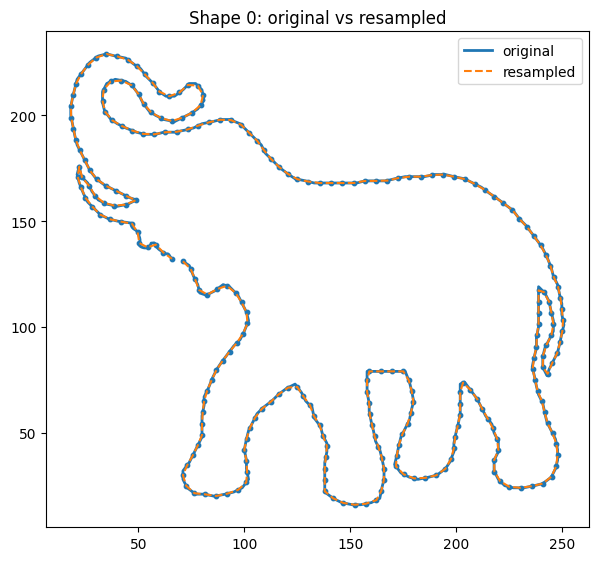

In [7]:
# %%
# ============================================================
# Cell 6. Visual sanity check for one shape
# ============================================================
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(xy[:, 0], xy[:, 1], label="original", lw=2)
ax.plot(xy_resampled[:, 0], xy_resampled[:, 1], "--", label="resampled", lw=1.5)

ax.scatter(xy_resampled[:, 0], xy_resampled[:, 1], s=10)
ax.set_aspect("equal")
ax.set_title(f"Shape {SHAPE_IDX}: original vs resampled")
ax.legend()
plt.show()

In [8]:
# %%
# ============================================================
# Cell 8. Feldman-Singh contourinfo
# - close Python port of the MATLAB implementation
# ============================================================
import numpy as np
from scipy.special import i0

def contourinfo(x, y, signed=False, resolution=3):
    """
    Python port of the MATLAB contourinfo function.

    Parameters
    ----------
    x, y : array-like
        Contour coordinates.
    signed : bool
        If True, use signed version.
        If False, use unsigned version.
    resolution : int
        Number of neighboring points on each side used to estimate turning.

    Returns
    -------
    surprisalmap : (N,) ndarray
    normalmap : (N, 2) ndarray
    x_used, y_used : (N,) ndarray
        Contour actually used internally.
    open_curve : bool
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(x) != len(y):
        raise ValueError("the x and y vectors defining the contour must have equal lengths!")

    N = len(x)
    b = 1.0  # spread term for the Von Mises distribution

    # MATLAB behavior:
    # if first and last point are identical, treat as closed and drop duplicate
    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N = N - 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N, 2), dtype=float)
    surprisalmap = np.zeros(N, dtype=float)

    for j in range(N):
        xprev = 0.0
        yprev = 0.0
        xnext = 0.0
        ynext = 0.0

        for k in range(1, resolution + 1):
            prev_idx = j - k
            next_idx = j + k

            if prev_idx < 0:
                prev_idx += N
            if next_idx >= N:
                next_idx -= N

            xprev += x[prev_idx]
            yprev += y[prev_idx]
            xnext += x[next_idx]
            ynext += y[next_idx]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        # vector from previous point average to current point
        vecprev = np.array([x[j] - xprev, y[j] - yprev], dtype=float)
        # vector from current point to next point average
        vecnext = np.array([xnext - x[j], ynext - y[j]], dtype=float)

        nprev = np.linalg.norm(vecprev)
        nnext = np.linalg.norm(vecnext)

        if nprev == 0 or nnext == 0:
            alpha = 0.0
        else:
            # turning magnitude from dot product
            cosval = np.dot(vecprev, vecnext) / (nprev * nnext)
            cosval = np.clip(cosval, -1.0, 1.0)
            alpha = np.arccos(cosval)

            # sign from 2D cross product z-component
            cp_z = vecprev[0] * vecnext[1] - vecprev[1] * vecnext[0]
            alpha = np.sign(cp_z) * alpha

        # surprisal using -log von Mises
        if signed:
            shift = 2 * np.pi / (N / resolution)   # same as MATLAB
            surprisal = -np.log(np.exp(b * np.cos(alpha - shift)) / (2 * np.pi * i0(b)))
        else:
            surprisal = -np.log(np.exp(b * np.cos(alpha)) / (2 * np.pi * i0(b)))

        # undefined near end points of an open contour
        if open_curve and ((j - resolution < 0) or (j + resolution >= N)):
            surprisal = 0.0

        # tangent and normal vectors
        tangvec = vecprev + vecnext
        tangnorm = np.linalg.norm(tangvec)

        if tangnorm == 0:
            normvec = np.array([0.0, 0.0], dtype=float)
        else:
            tangvec = tangvec / tangnorm
            # MATLAB: [[0 1; -1 0] * tangvec']'
            normvec = np.array([tangvec[1], -tangvec[0]], dtype=float)

        normalmap[j, :] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve

In [15]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

def contourinfo(x, y, signed=False, resolution=3):

    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)

    if len(x) != len(y):
        raise ValueError("x and y must have equal length")

    N = len(x)
    b = 1.0

    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N -= 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N,2))
    surprisalmap = np.zeros(N)

    for j in range(N):

        xprev = 0
        yprev = 0
        xnext = 0
        ynext = 0

        for k in range(1, resolution+1):

            prev = j-k
            nxt  = j+k

            if prev < 0:
                prev += N
            if nxt >= N:
                nxt -= N

            xprev += x[prev]
            yprev += y[prev]

            xnext += x[nxt]
            ynext += y[nxt]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        vecprev = np.array([x[j]-xprev, y[j]-yprev])
        vecnext = np.array([xnext-x[j], ynext-y[j]])

        n1 = np.linalg.norm(vecprev)
        n2 = np.linalg.norm(vecnext)

        if n1 == 0 or n2 == 0:
            alpha = 0
        else:
            cosv = np.dot(vecprev, vecnext)/(n1*n2)
            cosv = np.clip(cosv,-1,1)

            alpha = np.arccos(cosv)

            cp = vecprev[0]*vecnext[1] - vecprev[1]*vecnext[0]
            alpha = np.sign(cp)*alpha

        if signed:
            shift = 2*np.pi/(N/resolution)
            surprisal = -np.log(np.exp(b*np.cos(alpha-shift))/(2*np.pi*i0(b)))
        else:
            surprisal = -np.log(np.exp(b*np.cos(alpha))/(2*np.pi*i0(b)))

        if open_curve and ((j-resolution < 0) or (j+resolution >= N)):
            surprisal = 0

        tang = vecprev + vecnext
        tnorm = np.linalg.norm(tang)

        if tnorm == 0:
            normvec = np.array([0,0])
        else:
            tang = tang/tnorm
            normvec = np.array([tang[1], -tang[0]])

        normalmap[j] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve


def contourinfoplot(x, y, signed=False, resolution=3):

    surprisalmap, normalmap, x, y, open_curve = contourinfo(
        x, y, signed=signed, resolution=resolution
    )

    s = surprisalmap.copy()

    r = np.ptp(s)
    if r > 0:
        s = (s - s.min())/r
    else:
        s[:] = 0

    needlesize = max(np.ptp(x), np.ptp(y))/10

    normalmap[:,0] = s*normalmap[:,0]
    normalmap[:,1] = s*normalmap[:,1]

    xnormals = np.column_stack([x, x + needlesize*normalmap[:,0]])
    ynormals = np.column_stack([y, y + needlesize*normalmap[:,1]])

    fig, ax = plt.subplots(figsize=(6,6))

    ax.plot(x,y,'r')

    for i in range(len(x)):
        ax.plot(xnormals[i], ynormals[i],'k-')

    ax.set_aspect('equal')

    return s, surprisalmap, normalmap, xnormals, ynormals, ax

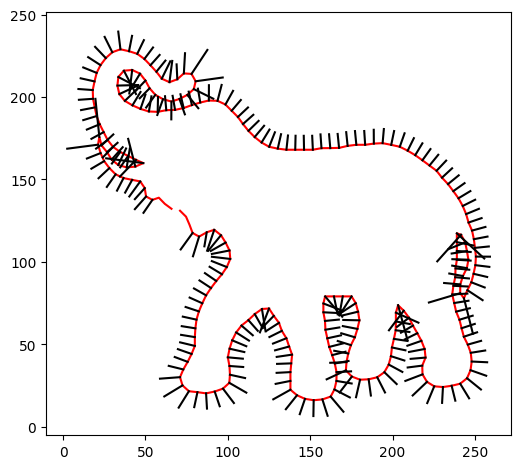

Raw surprisal shape: (256,)
Normalized surprisal shape: (256,)
Raw surprisal summary:
  min : 0.0
  max : 2.9858208570266425
  mean: 1.2686479132152542
  sum : 324.77386578310507


In [16]:
# %%
# ============================================================
# Cell 10. Compute Feldman-Singh surprisal for your resampled shape
# ============================================================
SIGNED = True
RESOLUTION = 3

x_r = xy_resampled[:, 0]
y_r = xy_resampled[:, 1]

s_norm, surprisal_raw, normalmap, xnormals, ynormals, ax = contourinfoplot(
    x_r,
    y_r,
    signed=SIGNED,
    resolution=RESOLUTION
)

plt.show()

print("Raw surprisal shape:", surprisal_raw.shape)
print("Normalized surprisal shape:", s_norm.shape)
print("Raw surprisal summary:")
print("  min :", float(np.min(surprisal_raw)))
print("  max :", float(np.max(surprisal_raw)))
print("  mean:", float(np.mean(surprisal_raw)))
print("  sum :", float(np.sum(surprisal_raw)))

In [17]:
from shapely.geometry import LineString, Polygon

line = LineString(xy_resampled)
print("Line is simple:", line.is_simple)

poly = Polygon(xy_resampled)
print("Polygon is valid:", poly.is_valid)
print("Polygon area:", poly.area)

Line is simple: True
Polygon is valid: True
Polygon area: 24390.55131952114


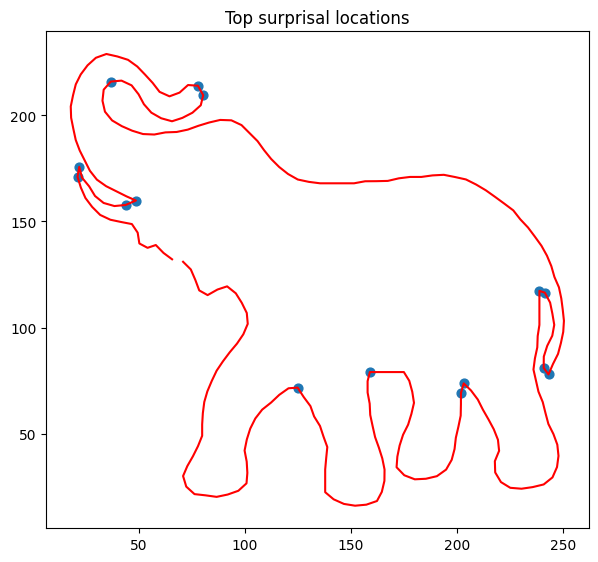

In [18]:
top_idx = np.argsort(surprisal_raw)[-15:]

fig, ax = plt.subplots(figsize=(7,7))
ax.plot(x_r, y_r, 'r-', lw=1.5)
ax.scatter(x_r[top_idx], y_r[top_idx], s=40)
ax.set_aspect("equal")
ax.set_title("Top surprisal locations")
plt.show()

In [20]:
# %%
# ============================================================
# Cell 14. Load silhouette and occluder from case JSONL
# ============================================================
from pathlib import Path
import json
import numpy as np

def load_case_from_jsonl(jsonl_path: Path, default_baseGrid: int = 256):
    row = json.loads(jsonl_path.read_text().splitlines()[-1])

    if "silhouette_u" in row:
        sil_u = np.asarray(row["silhouette_u"], float)
        occ_u = np.asarray(row.get("occluder_u", []), float)
        baseGrid = int(row["baseGrid"])
        sil_class = row.get("sil_class", None)

    else:
        sil_u = np.asarray(row["shape_contour_xy"], float)
        occ_u = np.asarray(row.get("occluder_rect_xy", []), float)
        baseGrid = int(row.get("baseGrid", default_baseGrid))
        sil_class = row.get("sil_class", row.get("category", None))

    if occ_u.size == 0:
        occ_u = np.zeros((0, 2), float)

    return sil_u, occ_u, baseGrid, sil_class


CASE_DIR = Path("/home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_high_small_1")
JSONL_PATH = CASE_DIR / "generated" / f"{CASE_DIR.name}.jsonl"

sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(JSONL_PATH)

print("JSONL:", JSONL_PATH)
print("sil_u shape:", sil_u.shape)
print("occ_u shape:", occ_u.shape)
print("baseGrid_case:", baseGrid_case)
print("sil_class:", sil_class)

JSONL: /home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_high_small_1/generated/elephant_7_high_small_1.jsonl
sil_u shape: (299, 2)
occ_u shape: (4, 2)
baseGrid_case: 256
sil_class: elephant


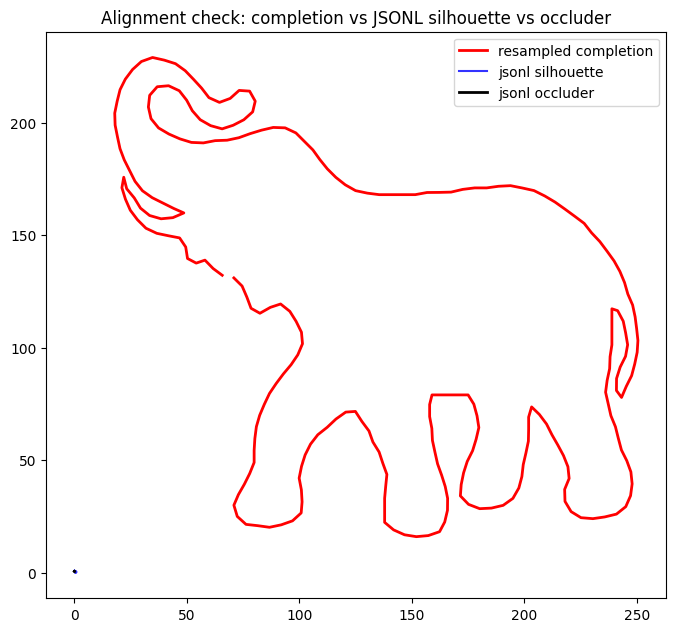

xy_resampled range x: 18.04589805874963 to 250.5675034708093
xy_resampled range y: 16.0 to 228.9629889513179
sil_u range x: 0.06611273334099105 to 0.9788767070828699
sil_u range y: 0.06002635632461541 to 0.8922745122671034
occ_u range x: 0.16196699141100893 to 0.26803300858899104
occ_u range y: 0.49196699141100897 to 0.5980330085889911
baseGrid_case: 256


In [22]:
# %%
# ============================================================
# Cell 14b. Verify coordinate alignment:
# - resampled completion
# - silhouette from JSONL
# - occluder from JSONL
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

# resampled completion
ax.plot(
    xy_resampled[:, 0],
    xy_resampled[:, 1],
    color="red",
    lw=2,
    label="resampled completion"
)

# silhouette from JSONL
if sil_u is not None and len(sil_u) > 0:
    sil_plot = np.asarray(sil_u, float)
    if sil_plot.ndim == 2 and sil_plot.shape[1] == 2:
        ax.plot(
            sil_plot[:, 0],
            sil_plot[:, 1],
            color="blue",
            lw=1.5,
            alpha=0.8,
            label="jsonl silhouette"
        )

# occluder from JSONL
if occ_u is not None and len(occ_u) > 0:
    occ_plot = np.asarray(occ_u, float)
    if occ_plot.ndim == 2 and occ_plot.shape[1] == 2:
        occ_closed = np.vstack([occ_plot, occ_plot[0]])
        ax.plot(
            occ_closed[:, 0],
            occ_closed[:, 1],
            color="black",
            lw=2,
            label="jsonl occluder"
        )

ax.set_aspect("equal")
ax.set_title("Alignment check: completion vs JSONL silhouette vs occluder")
ax.legend()
plt.show()

print("xy_resampled range x:", float(xy_resampled[:,0].min()), "to", float(xy_resampled[:,0].max()))
print("xy_resampled range y:", float(xy_resampled[:,1].min()), "to", float(xy_resampled[:,1].max()))

if sil_u is not None and len(sil_u) > 0:
    print("sil_u range x:", float(sil_u[:,0].min()), "to", float(sil_u[:,0].max()))
    print("sil_u range y:", float(sil_u[:,1].min()), "to", float(sil_u[:,1].max()))

if occ_u is not None and len(occ_u) > 0:
    print("occ_u range x:", float(occ_u[:,0].min()), "to", float(occ_u[:,0].max()))
    print("occ_u range y:", float(occ_u[:,1].min()), "to", float(occ_u[:,1].max()))

print("baseGrid_case:", baseGrid_case)

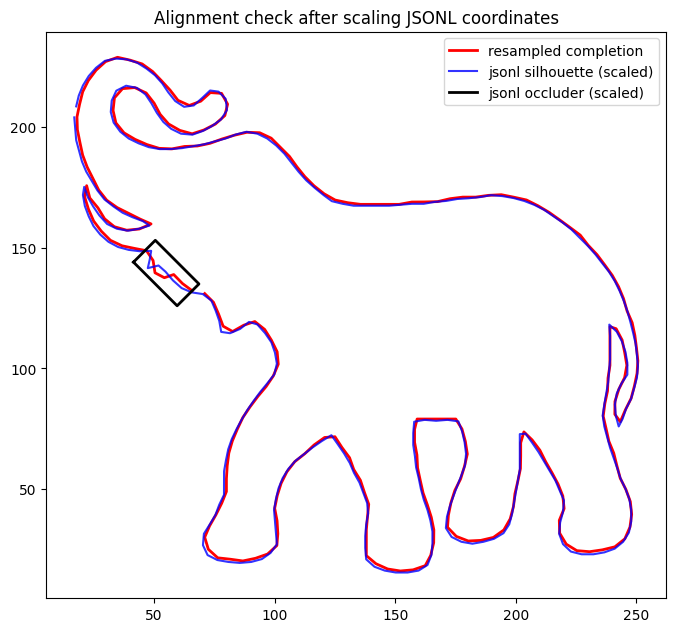

xy_resampled range x: 18.04589805874963 to 250.5675034708093
xy_resampled range y: 16.0 to 228.9629889513179
sil_px range x: 16.92485973529371 to 250.5924370132147
sil_px range y: 15.366747219101544 to 228.42227514037847
occ_px range x: 41.463549801218285 to 68.6164501987817
occ_px range y: 125.9435498012183 to 153.09645019878172


In [23]:
# %%
# ============================================================
# Cell 14b. Verify coordinate alignment after scaling JSONL coords
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

sil_px = sil_u * baseGrid_case
occ_px = occ_u * baseGrid_case

fig, ax = plt.subplots(figsize=(8, 8))

# resampled completion
ax.plot(
    xy_resampled[:, 0],
    xy_resampled[:, 1],
    color="red",
    lw=2,
    label="resampled completion"
)

# silhouette from JSONL, scaled to pixel space
if sil_px is not None and len(sil_px) > 0:
    ax.plot(
        sil_px[:, 0],
        sil_px[:, 1],
        color="blue",
        lw=1.5,
        alpha=0.8,
        label="jsonl silhouette (scaled)"
    )

# occluder from JSONL, scaled to pixel space
if occ_px is not None and len(occ_px) > 0:
    occ_closed = np.vstack([occ_px, occ_px[0]])
    ax.plot(
        occ_closed[:, 0],
        occ_closed[:, 1],
        color="black",
        lw=2,
        label="jsonl occluder (scaled)"
    )

ax.set_aspect("equal")
ax.set_title("Alignment check after scaling JSONL coordinates")
ax.legend()
plt.show()

print("xy_resampled range x:", float(xy_resampled[:,0].min()), "to", float(xy_resampled[:,0].max()))
print("xy_resampled range y:", float(xy_resampled[:,1].min()), "to", float(xy_resampled[:,1].max()))
print("sil_px range x:", float(sil_px[:,0].min()), "to", float(sil_px[:,0].max()))
print("sil_px range y:", float(sil_px[:,1].min()), "to", float(sil_px[:,1].max()))
print("occ_px range x:", float(occ_px[:,0].min()), "to", float(occ_px[:,0].max()))
print("occ_px range y:", float(occ_px[:,1].min()), "to", float(occ_px[:,1].max()))

In [24]:
# %%
# ============================================================
# Cell 15. Build point mask for contour points inside occluder
# - now using scaled occluder in pixel coordinates
# ============================================================
from shapely.geometry import Point, Polygon

if len(occ_px) < 3:
    raise ValueError("Occluder polygon has fewer than 3 points, cannot define occluded area.")

occ_poly = Polygon(occ_px)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

inside_occ = np.array(
    [occ_poly.covers(Point(x, y)) for x, y in xy_resampled],
    dtype=bool
)

print("Total contour points:", len(xy_resampled))
print("Points inside occluder:", int(inside_occ.sum()))
print("Fraction inside occluder:", float(inside_occ.mean()))

Total contour points: 256
Points inside occluder: 6
Fraction inside occluder: 0.0234375


In [26]:
# %%
# ============================================================
# Cell 16. Numerical Feldman-Singh value for the occluded segment
# - uses raw surprisal, not normalized plotting values
# ============================================================
fs_inside_raw = surprisal_raw[inside_occ]
idx_inside = np.where(inside_occ)[0]

print("Number of contour points inside occluder:", len(fs_inside_raw))

if len(fs_inside_raw) == 0:
    print("No contour points fall inside the occluder.")
else:
    fs_inside_sum = float(np.sum(fs_inside_raw))
    fs_inside_mean = float(np.mean(fs_inside_raw))
    fs_inside_max = float(np.max(fs_inside_raw))
    fs_inside_min = float(np.min(fs_inside_raw))

    print("Occluded-segment Feldman-Singh values:")
    print("  sum  :", fs_inside_sum)
    print("  mean :", fs_inside_mean)
    print("  max  :", fs_inside_max)
    print("  min  :", fs_inside_min)

Number of contour points inside occluder: 6
Occluded-segment Feldman-Singh values:
  sum  : 5.146215204519004
  mean : 0.8577025340865007
  max  : 1.449393093225405
  min  : 0.0


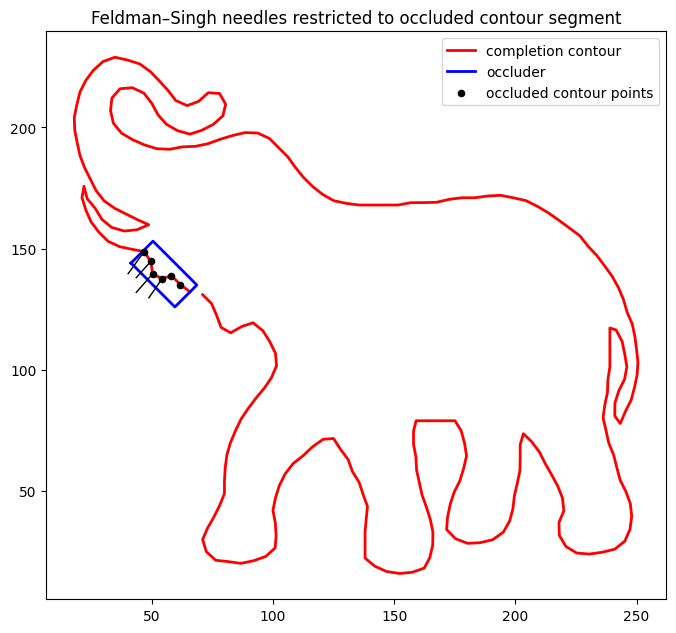

In [27]:
# %%
# ============================================================
# Cell 17. Needle plot restricted to the occluded contour segment
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# normalized values already computed earlier
# s_norm, surprisal_raw, normalmap, xnormals, ynormals = ...

fig, ax = plt.subplots(figsize=(8,8))

# full contour
ax.plot(
    xy_resampled[:,0],
    xy_resampled[:,1],
    color="red",
    lw=2,
    label="completion contour"
)

# occluder
occ_closed = np.vstack([occ_px, occ_px[0]])
ax.plot(
    occ_closed[:,0],
    occ_closed[:,1],
    color="blue",
    lw=2,
    label="occluder"
)

# draw needles only where contour is inside occluder
idx_inside = np.where(inside_occ)[0]

for i in idx_inside:
    ax.plot(
        xnormals[i],
        ynormals[i],
        color="black",
        lw=1
    )

# highlight contour points inside occluder
ax.scatter(
    xy_resampled[idx_inside,0],
    xy_resampled[idx_inside,1],
    s=20,
    color="black",
    zorder=3,
    label="occluded contour points"
)

ax.set_aspect("equal")
ax.set_title("Feldman–Singh needles restricted to occluded contour segment")
ax.legend()
plt.show()

# Multicase flow

In [ ]:
# %%
# ============================================================
# Cell 1. Imports and paths
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import i0
from shapely.geometry import Point, Polygon

CASE_DIR = Path("/home/hschatzle/monte-carlo-selection/results/contrasts/bgmm_elephant_texture_low_large/elephant_7_low_large_1")
CASE_ID = CASE_DIR.name

CASE_GEOM_DIR = Path("/home/hschatzle/monte-carlo-selection/data/cases/contrasts") / CASE_ID
JSONL_PATH = CASE_GEOM_DIR / "generated" / f"{CASE_ID}.jsonl"
SHAPES_NPZ = CASE_GEOM_DIR / "generated" / "shapes_xy.npz"

COMPONENTS_JSONL = CASE_DIR / "components.jsonl"
SHAPE_TO_CLUSTER_JSONL = CASE_DIR / "shape_to_cluster.jsonl"

assert JSONL_PATH.exists(), f"Missing {JSONL_PATH}"
assert SHAPES_NPZ.exists(), f"Missing {SHAPES_NPZ}"
assert COMPONENTS_JSONL.exists(), f"Missing {COMPONENTS_JSONL}"
assert SHAPE_TO_CLUSTER_JSONL.exists(), f"Missing {SHAPE_TO_CLUSTER_JSONL}"

TOP_K_CLUSTERS = 5
N_POINTS_SHAPE = 256
N_POINTS_OCCLUDER = 128
FS_SIGNED = True
FS_RESOLUTION = 3

print("CASE_ID:", CASE_ID)
print("CASE_GEOM_DIR:", CASE_GEOM_DIR)
print("CASE_DIR:", CASE_DIR)

CASE_ID: elephant_7_low_large_1
CASE_GEOM_DIR: /home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_low_large_1
CASE_DIR: /home/hschatzle/monte-carlo-selection/results/contrasts/bgmm_elephant_texture_low_large/elephant_7_low_large_1


In [95]:
# %%
# ============================================================
# Cell 2. Helper functions
# ============================================================
def load_jsonl_rows(path: Path):
    rows = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_case_from_jsonl(jsonl_path: Path, default_baseGrid: int = 256):
    row = json.loads(jsonl_path.read_text().splitlines()[-1])

    if "silhouette_u" in row:
        sil_u = np.asarray(row["silhouette_u"], float)
        occ_u = np.asarray(row.get("occluder_u", []), float)
        baseGrid = int(row["baseGrid"])
        sil_class = row.get("sil_class", None)
    else:
        sil_u = np.asarray(row["shape_contour_xy"], float)
        occ_u = np.asarray(row.get("occluder_rect_xy", []), float)
        baseGrid = int(row.get("baseGrid", default_baseGrid))
        sil_class = row.get("sil_class", row.get("category", None))

    if occ_u.size == 0:
        occ_u = np.zeros((0, 2), float)

    return sil_u, occ_u, baseGrid, sil_class


def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    poly = np.asarray(poly, dtype=float)

    if poly.ndim != 2:
        raise ValueError(f"Expected 2D polygon array, got shape {poly.shape}")

    if poly.shape[1] == 2:
        xy = poly.copy()
    elif poly.shape[0] == 2:
        xy = poly.T.copy()
    else:
        raise ValueError(f"Could not interpret polygon with shape {poly.shape}")

    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]

    return xy


def signed_polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def ensure_ccw(xy):
    return xy[::-1].copy() if signed_polygon_area(xy) < 0 else xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)
    assert xy.ndim == 2 and xy.shape[1] == 2, f"Expected (N,2), got {xy.shape}"

    pts = xy.copy()

    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])

        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        s_new = np.linspace(0.0, total_len, n_points, endpoint=False)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

    diffs = np.diff(pts, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seglen)])
    total_len = s[-1]

    if total_len == 0:
        raise ValueError("Degenerate contour with zero total length")

    s_new = np.linspace(0.0, total_len, n_points)
    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    return np.column_stack([x_new, y_new])


def contourinfo(x, y, signed=False, resolution=3):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(x) != len(y):
        raise ValueError("x and y must have equal length")

    N = len(x)
    b = 1.0

    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N -= 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N, 2), dtype=float)
    surprisalmap = np.zeros(N, dtype=float)

    for j in range(N):
        xprev = 0.0
        yprev = 0.0
        xnext = 0.0
        ynext = 0.0

        for k in range(1, resolution + 1):
            prev_idx = j - k
            next_idx = j + k

            if prev_idx < 0:
                prev_idx += N
            if next_idx >= N:
                next_idx -= N

            xprev += x[prev_idx]
            yprev += y[prev_idx]
            xnext += x[next_idx]
            ynext += y[next_idx]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        vecprev = np.array([x[j] - xprev, y[j] - yprev], dtype=float)
        vecnext = np.array([xnext - x[j], ynext - y[j]], dtype=float)

        n1 = np.linalg.norm(vecprev)
        n2 = np.linalg.norm(vecnext)

        if n1 == 0 or n2 == 0:
            alpha = 0.0
        else:
            cosv = np.dot(vecprev, vecnext) / (n1 * n2)
            cosv = np.clip(cosv, -1.0, 1.0)
            alpha = np.arccos(cosv)

            cp = vecprev[0] * vecnext[1] - vecprev[1] * vecnext[0]
            alpha = np.sign(cp) * alpha

        if signed:
            shift = 2 * np.pi / (N / resolution)
            surprisal = -np.log(np.exp(b * np.cos(alpha - shift)) / (2 * np.pi * i0(b)))
        else:
            surprisal = -np.log(np.exp(b * np.cos(alpha)) / (2 * np.pi * i0(b)))

        if open_curve and ((j - resolution < 0) or (j + resolution >= N)):
            surprisal = 0.0

        tang = vecprev + vecnext
        tnorm = np.linalg.norm(tang)

        if tnorm == 0:
            normvec = np.array([0.0, 0.0], dtype=float)
        else:
            tang = tang / tnorm
            normvec = np.array([tang[1], -tang[0]], dtype=float)

        normalmap[j] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve


def contourinfoplot_arrays(x, y, signed=False, resolution=3):
    surprisal_raw, normalmap, x_used, y_used, open_curve = contourinfo(
        x, y, signed=signed, resolution=resolution
    )

    s_norm = surprisal_raw.copy()
    r = np.ptp(s_norm)
    if r > 0:
        s_norm = (s_norm - s_norm.min()) / r
    else:
        s_norm[:] = 0.0

    needlesize = max(np.ptp(x_used), np.ptp(y_used)) / 10.0

    normal_scaled = normalmap.copy()
    normal_scaled[:, 0] = s_norm * normal_scaled[:, 0]
    normal_scaled[:, 1] = s_norm * normal_scaled[:, 1]

    xnormals = np.column_stack([x_used, x_used + needlesize * normal_scaled[:, 0]])
    ynormals = np.column_stack([y_used, y_used + needlesize * normal_scaled[:, 1]])

    return s_norm, surprisal_raw, normalmap, xnormals, ynormals


def arc_length_inside_mask(xy, mask):
    xy = np.asarray(xy, float)
    mask = np.asarray(mask, bool)

    pts2 = np.vstack([xy, xy[0]])
    diffs = np.diff(pts2, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))

    mask_next = np.roll(mask, -1)
    seg_inside = mask & mask_next

    return float(seglen[seg_inside].sum())


def responsibility_dict_from_top5(resp_top5):
    out = {}
    for d in resp_top5:
        out[int(d["k"])] = float(d["p"])
    return out

In [96]:
# %%
# ============================================================
# Cell 3. Load case geometry and scale to pixel coordinates
# ============================================================
sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(JSONL_PATH)

sil_px = sil_u * baseGrid_case
occ_px = occ_u * baseGrid_case

occ_px_resampled = resample_contour_arc_length(
    ensure_ccw(occ_px),
    n_points=N_POINTS_OCCLUDER,
    closed=True
)

occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

print("baseGrid_case:", baseGrid_case)
print("sil_class:", sil_class)
print("sil_px range x:", float(sil_px[:, 0].min()), "to", float(sil_px[:, 0].max()))
print("sil_px range y:", float(sil_px[:, 1].min()), "to", float(sil_px[:, 1].max()))
print("occ_px range x:", float(occ_px[:, 0].min()), "to", float(occ_px[:, 0].max()))
print("occ_px range y:", float(occ_px[:, 1].min()), "to", float(occ_px[:, 1].max()))
print("Resampled occluder valid:", occ_poly.is_valid)

baseGrid_case: 256
sil_class: elephant
sil_px range x: 16.92485973529371 to 250.5924370132147
sil_px range y: 15.366747219101544 to 228.42227514037847
occ_px range x: 128.0 to 204.8
occ_px range y: 152.32000000000002 to 190.72
Resampled occluder valid: True


In [97]:
# %%
# ============================================================
# Cell 4. Load shapes and cluster files
# ============================================================
npz = np.load(SHAPES_NPZ, allow_pickle=True)
polygons = npz["polygons"]
out_files = npz["out_files"]

components_rows = load_jsonl_rows(COMPONENTS_JSONL)
shape_rows = load_jsonl_rows(SHAPE_TO_CLUSTER_JSONL)

df_comp = pd.DataFrame(components_rows)
df_shape = pd.DataFrame(shape_rows)

print("polygons:", len(polygons))
print("out_files:", len(out_files))
print("df_comp shape:", df_comp.shape)
print("df_shape shape:", df_shape.shape)

display(df_comp.head(3))
display(df_shape.head(3))

polygons: 10000
out_files: 10000
df_comp shape: (80, 8)
df_shape shape: (10000, 8)


,timestamp_utc,case_id,k,mix_weight,mass_raw,mass_debias,is_active,active_rank_by_mass_debias
0,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,0,0.002602,25.027144,25.027144,True,19.0
1,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,1,0.145147,1450.854229,1450.854229,True,4.0
2,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,2,0.101977,1019.103142,1019.103142,True,6.0


,timestamp_utc,case_id,eligible_row,global_index,png,k_argmax,k_rank_among_active,resp_top5
0,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,0,0,/home/hschatzle/monte-carlo-selection/data/cas...,59,2,"[{'k': 59, 'p': 0.9289279831706116}, {'k': 7, ..."
1,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,1,1,/home/hschatzle/monte-carlo-selection/data/cas...,3,3,"[{'k': 3, 'p': 0.710320185878825}, {'k': 30, '..."
2,2026-03-05T07:07:17+00:00,elephant_7_low_large_1,2,2,/home/hschatzle/monte-carlo-selection/data/cas...,50,8,"[{'k': 50, 'p': 0.5727399575810431}, {'k': 7, ..."


In [98]:
# %%
# ============================================================
# Cell 5. Select top active clusters by mass_debias
# ============================================================
df_comp_active = df_comp[df_comp["is_active"] == True].copy()
df_comp_sel = df_comp_active[df_comp_active["active_rank_by_mass_debias"] <= TOP_K_CLUSTERS].copy()
df_comp_sel = df_comp_sel.sort_values("active_rank_by_mass_debias").reset_index(drop=True)

assert len(df_comp_sel) > 0, "No selected active clusters found."

selected_ks = set(df_comp_sel["k"].astype(int).tolist())

mass_sum = df_comp_sel["mass_debias"].sum()
df_comp_sel["cluster_weight"] = df_comp_sel["mass_debias"] / mass_sum

cluster_weight_map = dict(zip(df_comp_sel["k"].astype(int), df_comp_sel["cluster_weight"].astype(float)))

print("Selected active clusters:")
display(df_comp_sel[["k", "mass_debias", "active_rank_by_mass_debias", "cluster_weight"]])

print("Selected ks:", sorted(selected_ks))
print("Sum cluster weights:", float(df_comp_sel["cluster_weight"].sum()))

Selected active clusters:


,k,mass_debias,active_rank_by_mass_debias,cluster_weight
0,7,1985.470026,1.0,0.240210
1,59,1769.823957,2.0,0.214121
2,3,1746.577249,3.0,0.211308
3,1,1450.854229,4.0,0.175530
4,30,1312.817542,5.0,0.158830


Selected ks: [1, 3, 7, 30, 59]
Sum cluster weights: 1.0000000000000002


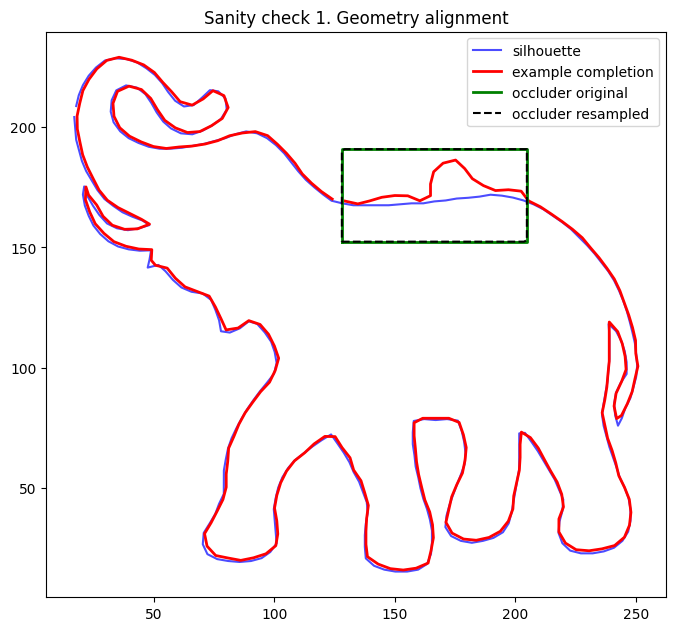

example_idx: 0
example png: /home/hschatzle/monte-carlo-selection/data/cases/contrasts/elephant_7_low_large_1/generated/completions/completion_0001_00001.png
example k_argmax: 59


In [99]:
# %%
# ============================================================
# Cell 6. Visual sanity check 1
# - silhouette
# - original occluder
# - resampled occluder
# - one example selected completion
# ============================================================
example_row = df_shape[df_shape["k_argmax"].isin(selected_ks)].iloc[0]
example_idx = int(example_row["global_index"])

xy_example = polygon_to_xy(polygons[example_idx], drop_duplicate_endpoint=True)
xy_example = ensure_ccw(xy_example)
xy_example_res = resample_contour_arc_length(xy_example, n_points=N_POINTS_SHAPE, closed=True)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(sil_px[:, 0], sil_px[:, 1], color="blue", lw=1.5, alpha=0.7, label="silhouette")
ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="example completion")

occ_closed = np.vstack([occ_px, occ_px[0]])
ax.plot(occ_closed[:, 0], occ_closed[:, 1], color="green", lw=2, label="occluder original")

occ_res_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="black", lw=1.5, linestyle="--", label="occluder resampled")

ax.set_aspect("equal")
ax.set_title("Sanity check 1. Geometry alignment")
ax.legend()
plt.show()

print("example_idx:", example_idx)
print("example png:", example_row["png"])
print("example k_argmax:", int(example_row["k_argmax"]))

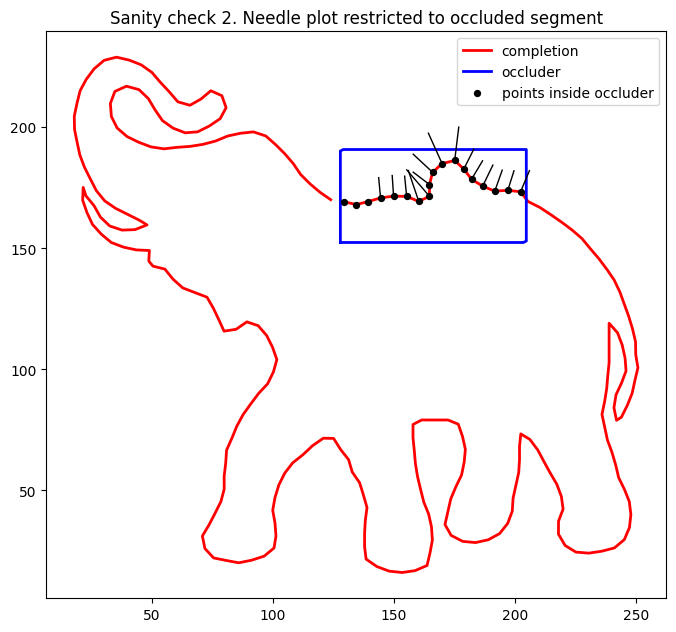

n_inside: 18
fs_inside_sum: 19.921161712385533
fs_inside_mean: 1.1067312062436407
fs_inside_arclen: 89.61429070558938
fs_inside_density: 0.22229893865736997


In [100]:
# %%
# ============================================================
# Cell 7. Visual sanity check 2
# - one example needle plot restricted to occluded contour points
# ============================================================
s_norm_ex, surprisal_raw_ex, normalmap_ex, xnormals_ex, ynormals_ex = contourinfoplot_arrays(
    xy_example_res[:, 0],
    xy_example_res[:, 1],
    signed=FS_SIGNED,
    resolution=FS_RESOLUTION
)

inside_occ_ex = np.array(
    [occ_poly.covers(Point(x, y)) for x, y in xy_example_res],
    dtype=bool
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="completion")
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="blue", lw=2, label="occluder")

idx_inside_ex = np.where(inside_occ_ex)[0]
for i in idx_inside_ex:
    ax.plot(xnormals_ex[i], ynormals_ex[i], color="black", lw=1)

ax.scatter(
    xy_example_res[idx_inside_ex, 0],
    xy_example_res[idx_inside_ex, 1],
    s=18,
    color="black",
    zorder=3,
    label="points inside occluder"
)

ax.set_aspect("equal")
ax.set_title("Sanity check 2. Needle plot restricted to occluded segment")
ax.legend()
plt.show()

fs_inside_sum_ex = float(np.sum(surprisal_raw_ex[inside_occ_ex]))
fs_inside_mean_ex = float(np.mean(surprisal_raw_ex[inside_occ_ex])) if inside_occ_ex.any() else np.nan
fs_inside_arclen_ex = arc_length_inside_mask(xy_example_res, inside_occ_ex)
fs_inside_density_ex = fs_inside_sum_ex / fs_inside_arclen_ex if fs_inside_arclen_ex > 0 else np.nan

print("n_inside:", int(inside_occ_ex.sum()))
print("fs_inside_sum:", fs_inside_sum_ex)
print("fs_inside_mean:", fs_inside_mean_ex)
print("fs_inside_arclen:", fs_inside_arclen_ex)
print("fs_inside_density:", fs_inside_density_ex)

In [101]:
# %%
# Faster worker setup. Replaces the helper block above.

from concurrent.futures import ProcessPoolExecutor
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon

N_WORKERS = 30

df_shape_sel = df_shape[df_shape["k_argmax"].isin(selected_ks)].copy().reset_index(drop=True)
print("Shapes with k_argmax in selected ks:", len(df_shape_sel))

_POLYGONS = None
_OCC_POLY = None
_N_POINTS_SHAPE = None
_FS_SIGNED = None
_FS_RESOLUTION = None


def _init_fs_worker(polygons_shared, occ_coords_shared, n_points_shape_shared, fs_signed_shared, fs_resolution_shared):
    global _POLYGONS, _OCC_POLY, _N_POINTS_SHAPE, _FS_SIGNED, _FS_RESOLUTION
    _POLYGONS = polygons_shared
    _OCC_POLY = Polygon(np.asarray(occ_coords_shared, dtype=float))
    if not _OCC_POLY.is_valid:
        _OCC_POLY = _OCC_POLY.buffer(0)
    _N_POINTS_SHAPE = int(n_points_shape_shared)
    _FS_SIGNED = bool(fs_signed_shared)
    _FS_RESOLUTION = int(fs_resolution_shared)


def _worker_compute_fs_metric(task):
    row = task

    global_index = int(row["global_index"])
    k_argmax = int(row["k_argmax"])
    k_rank_among_active = row.get("k_rank_among_active", None)

    xy = polygon_to_xy(_POLYGONS[global_index], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    xy_res = resample_contour_arc_length(xy, n_points=_N_POINTS_SHAPE, closed=True)

    s_norm, surprisal_raw, normalmap, xnormals, ynormals = contourinfoplot_arrays(
        xy_res[:, 0],
        xy_res[:, 1],
        signed=_FS_SIGNED,
        resolution=_FS_RESOLUTION
    )

    inside_occ = np.array(
        [_OCC_POLY.covers(Point(x, y)) for x, y in xy_res],
        dtype=bool
    )

    n_inside = int(inside_occ.sum())
    fs_inside_sum = float(np.sum(surprisal_raw[inside_occ])) if n_inside > 0 else 0.0
    fs_inside_mean = float(np.mean(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_max = float(np.max(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_min = float(np.min(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan

    arclen_inside = arc_length_inside_mask(xy_res, inside_occ)
    fs_inside_density = fs_inside_sum / arclen_inside if arclen_inside > 0 else np.nan

    resp_dict = responsibility_dict_from_top5(row["resp_top5"])

    return {
        "case_id": row["case_id"],
        "eligible_row": int(row["eligible_row"]),
        "global_index": global_index,
        "png": row["png"],
        "k_argmax": k_argmax,
        "k_rank_among_active": k_rank_among_active,
        "n_inside": n_inside,
        "fs_inside_sum": fs_inside_sum,
        "fs_inside_mean": fs_inside_mean,
        "fs_inside_max": fs_inside_max,
        "fs_inside_min": fs_inside_min,
        "arclen_inside": arclen_inside,
        "fs_inside_density": fs_inside_density,
        "resp_dict": resp_dict,
    }


tasks = df_shape_sel.to_dict(orient="records")
occ_coords_shared = np.asarray(occ_poly.exterior.coords[:-1], dtype=float)

with ProcessPoolExecutor(
    max_workers=N_WORKERS,
    initializer=_init_fs_worker,
    initargs=(
        polygons,
        occ_coords_shared,
        N_POINTS_SHAPE,
        FS_SIGNED,
        FS_RESOLUTION,
    ),
) as ex:
    rows_metrics = list(ex.map(_worker_compute_fs_metric, tasks, chunksize=32))

df_metrics = pd.DataFrame(rows_metrics)

print("df_metrics shape:", df_metrics.shape)
display(df_metrics.head())

Shapes with k_argmax in selected ks: 8285
df_metrics shape: (8285, 14)


,case_id,eligible_row,global_index,png,k_argmax,k_rank_among_active,n_inside,fs_inside_sum,fs_inside_mean,fs_inside_max,fs_inside_min,arclen_inside,fs_inside_density,resp_dict
0,elephant_7_low_large_1,0,0,/home/hschatzle/monte-carlo-selection/data/cas...,59,2,18,19.921162,1.106731,1.849471,0.0,89.614291,0.222299,"{59: 0.9289279831706116, 7: 0.0651759256015925..."
1,elephant_7_low_large_1,1,1,/home/hschatzle/monte-carlo-selection/data/cas...,3,3,24,30.999690,1.291654,2.835171,0.0,123.499080,0.251012,"{3: 0.710320185878825, 30: 0.2706298091051912,..."
2,elephant_7_low_large_1,4,4,/home/hschatzle/monte-carlo-selection/data/cas...,1,4,25,33.113553,1.324542,2.570664,0.0,125.846405,0.263127,"{1: 0.657370328126176, 3: 0.34132477450757714,..."
3,elephant_7_low_large_1,5,5,/home/hschatzle/monte-carlo-selection/data/cas...,7,1,17,16.213990,0.953764,1.317393,0.0,84.231680,0.192493,"{7: 0.9060574434862338, 2: 0.0938577083099868,..."
4,elephant_7_low_large_1,6,6,/home/hschatzle/monte-carlo-selection/data/cas...,7,1,19,20.847429,1.097233,2.076594,0.0,92.978466,0.224218,"{7: 0.9900309756588421, 2: 0.00923487503514769..."


In [102]:
# %%
# ============================================================
# Cell 9. Hard cluster means
# - uses k_argmax as cluster membership
# - then weights cluster means by normalized mass_debias
# ============================================================
cluster_hard = (
    df_metrics
    .groupby("k_argmax", as_index=False)
    .agg(
        n_shapes=("global_index", "count"),
        mean_fs_inside_sum=("fs_inside_sum", "mean"),
        mean_fs_inside_mean=("fs_inside_mean", "mean"),
        mean_fs_inside_density=("fs_inside_density", "mean"),
        mean_n_inside=("n_inside", "mean"),
        mean_arclen_inside=("arclen_inside", "mean"),
    )
    .rename(columns={"k_argmax": "k"})
)

cluster_hard = cluster_hard.merge(
    df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
    on="k",
    how="left"
)

cluster_hard["weighted_sum_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_sum"]
cluster_hard["weighted_mean_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_mean"]
cluster_hard["weighted_density_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_density"]

display(cluster_hard.sort_values("active_rank_by_mass_debias"))

expected_fs_hard_sum = float(cluster_hard["weighted_sum_metric"].sum())
expected_fs_hard_mean = float(cluster_hard["weighted_mean_metric"].sum())
expected_fs_hard_density = float(cluster_hard["weighted_density_metric"].sum())

print("Hard cluster-weighted expected FS")
print("  expected_fs_inside_sum     :", expected_fs_hard_sum)
print("  expected_fs_inside_mean    :", expected_fs_hard_mean)
print("  expected_fs_inside_density :", expected_fs_hard_density)

,k,n_shapes,mean_fs_inside_sum,mean_fs_inside_mean,mean_fs_inside_density,mean_n_inside,mean_arclen_inside,active_rank_by_mass_debias,mass_debias,cluster_weight,weighted_sum_metric,weighted_mean_metric,weighted_density_metric
2,7,1974,20.432614,1.053623,0.211689,18.873354,94.061972,1.0,1985.470026,0.240210,4.908128,0.253091,0.050850
4,59,1776,22.188245,1.092557,0.218752,19.603041,98.118484,2.0,1769.823957,0.214121,4.750963,0.233939,0.046839
1,3,1768,25.056496,1.144549,0.228416,20.985294,105.557838,3.0,1746.577249,0.211308,5.294644,0.241853,0.048266
0,1,1450,23.900593,1.128591,0.226061,20.448966,102.394384,4.0,1450.854229,0.175530,4.195281,0.198102,0.039681
3,30,1317,25.087988,1.146438,0.228342,21.030372,105.917244,5.0,1312.817542,0.158830,3.984729,0.182089,0.036268


Hard cluster-weighted expected FS
  expected_fs_inside_sum     : 23.133744917984174
  expected_fs_inside_mean    : 1.1090741319354358
  expected_fs_inside_density : 0.22190366698387504


In [103]:
# %%
# ============================================================
# Cell 10. Soft responsibility-weighted cluster means
# - uses resp_top5 probabilities to weight shape contributions
# - approximate, because only top5 responsibilities are stored
# ============================================================
soft_rows = []

for _, row in df_metrics.iterrows():
    for k, p in row["resp_dict"].items():
        if k in selected_ks:
            soft_rows.append({
                "global_index": row["global_index"],
                "k": int(k),
                "resp_p": float(p),
                "fs_inside_sum": float(row["fs_inside_sum"]),
                "fs_inside_mean": float(row["fs_inside_mean"]) if pd.notnull(row["fs_inside_mean"]) else np.nan,
                "fs_inside_density": float(row["fs_inside_density"]) if pd.notnull(row["fs_inside_density"]) else np.nan,
            })

df_soft = pd.DataFrame(soft_rows)

soft_group = (
    df_soft
    .groupby("k", as_index=False)
    .apply(
        lambda g: pd.Series({
            "resp_mass_seen": g["resp_p"].sum(),
            "soft_mean_fs_inside_sum": np.average(g["fs_inside_sum"], weights=g["resp_p"]) if g["resp_p"].sum() > 0 else np.nan,
            "soft_mean_fs_inside_mean": np.average(g["fs_inside_mean"].dropna(), weights=g.loc[g["fs_inside_mean"].notna(), "resp_p"]) if g["fs_inside_mean"].notna().any() else np.nan,
            "soft_mean_fs_inside_density": np.average(g["fs_inside_density"].dropna(), weights=g.loc[g["fs_inside_density"].notna(), "resp_p"]) if g["fs_inside_density"].notna().any() else np.nan,
        })
    )
    .reset_index(drop=True)
)

soft_group = soft_group.merge(
    df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
    on="k",
    how="left"
)

soft_group["weighted_sum_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_sum"]
soft_group["weighted_mean_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_mean"]
soft_group["weighted_density_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_density"]

display(soft_group.sort_values("active_rank_by_mass_debias"))

expected_fs_soft_sum = float(soft_group["weighted_sum_metric"].sum())
expected_fs_soft_mean = float(soft_group["weighted_mean_metric"].sum())
expected_fs_soft_density = float(soft_group["weighted_density_metric"].sum())

print("Soft responsibility-weighted expected FS")
print("  expected_fs_inside_sum     :", expected_fs_soft_sum)
print("  expected_fs_inside_mean    :", expected_fs_soft_mean)
print("  expected_fs_inside_density :", expected_fs_soft_density)

,k,resp_mass_seen,soft_mean_fs_inside_sum,soft_mean_fs_inside_mean,soft_mean_fs_inside_density,active_rank_by_mass_debias,mass_debias,cluster_weight,weighted_sum_metric,weighted_mean_metric,weighted_density_metric
2,7,1919.411973,20.410992,1.053065,0.211529,1.0,1985.470026,0.240210,4.902934,0.252957,0.050812
4,59,1747.476315,22.049733,1.090325,0.218312,2.0,1769.823957,0.214121,4.721305,0.233461,0.046745
1,3,1731.687683,24.840577,1.140766,0.227786,3.0,1746.577249,0.211308,5.249018,0.241053,0.048133
0,1,1433.027858,23.774932,1.126400,0.225588,4.0,1450.854229,0.175530,4.173224,0.197717,0.039598
3,30,1299.016368,24.976111,1.145157,0.228184,5.0,1312.817542,0.158830,3.966960,0.181885,0.036242


Soft responsibility-weighted expected FS
  expected_fs_inside_sum     : 23.01344074926411
  expected_fs_inside_mean    : 1.1070746524887283
  expected_fs_inside_density : 0.22152981187818585


In [104]:
# %%
# ============================================================
# Cell 11. Summary object for this case
# ============================================================
summary_case = pd.DataFrame([{
    "case_id": CASE_ID,
    "top_k_clusters": TOP_K_CLUSTERS,
    "n_selected_clusters": len(selected_ks),
    "n_shapes_selected_hard": len(df_metrics),
    "expected_fs_hard_sum": expected_fs_hard_sum,
    "expected_fs_hard_mean": expected_fs_hard_mean,
    "expected_fs_hard_density": expected_fs_hard_density,
    "expected_fs_soft_sum": expected_fs_soft_sum,
    "expected_fs_soft_mean": expected_fs_soft_mean,
    "expected_fs_soft_density": expected_fs_soft_density,
    "fs_signed": FS_SIGNED,
    "fs_resolution": FS_RESOLUTION,
    "n_points_shape": N_POINTS_SHAPE,
    "n_points_occluder": N_POINTS_OCCLUDER,
}])

display(summary_case)

,case_id,top_k_clusters,n_selected_clusters,n_shapes_selected_hard,expected_fs_hard_sum,expected_fs_hard_mean,expected_fs_hard_density,expected_fs_soft_sum,expected_fs_soft_mean,expected_fs_soft_density,fs_signed,fs_resolution,n_points_shape,n_points_occluder
0,elephant_7_low_large_1,5,5,8285,23.133745,1.109074,0.221904,23.013441,1.107075,0.22153,True,3,256,128


# Multicase-Multiiter

In [131]:
# %%
# ============================================================
# Cell 1. Imports, config, multicase paths
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import i0
from shapely.geometry import Point, Polygon
from concurrent.futures import ProcessPoolExecutor

RESULTS_ROOT = Path("/home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_8")
GEOM_ROOT = Path("/home/hschatzle/monte-carlo-selection/data/cases/symmetry")

CASE_IDS = [f"butterfly_48_symmetrical_8_{i}" for i in range(1, 2)]

TOP_K_CLUSTERS = 5
N_POINTS_SHAPE = 256
N_POINTS_OCCLUDER = 128
FS_SIGNED = True
FS_RESOLUTION = 3
N_WORKERS = 30

print("RESULTS_ROOT:", RESULTS_ROOT)
print("GEOM_ROOT:", GEOM_ROOT)
print("N cases:", len(CASE_IDS))
print("First few CASE_IDS:", CASE_IDS[:3])

RESULTS_ROOT: /home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_8
GEOM_ROOT: /home/hschatzle/monte-carlo-selection/data/cases/symmetry
N cases: 1
First few CASE_IDS: ['butterfly_48_symmetrical_8_1']


In [130]:
# %%
# ============================================================
# Cell 2. Helper functions
# ============================================================
def load_jsonl_rows(path: Path):
    rows = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_case_from_jsonl(jsonl_path: Path, default_baseGrid: int = 256):
    row = json.loads(jsonl_path.read_text().splitlines()[-1])

    if "silhouette_u" in row:
        sil_u = np.asarray(row["silhouette_u"], float)
        occ_u = np.asarray(row.get("occluder_u", []), float)
        baseGrid = int(row["baseGrid"])
        sil_class = row.get("sil_class", None)
    else:
        sil_u = np.asarray(row["shape_contour_xy"], float)
        occ_u = np.asarray(row.get("occluder_rect_xy", []), float)
        baseGrid = int(row.get("baseGrid", default_baseGrid))
        sil_class = row.get("sil_class", row.get("category", None))

    if occ_u.size == 0:
        occ_u = np.zeros((0, 2), float)

    return sil_u, occ_u, baseGrid, sil_class


def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    poly = np.asarray(poly, dtype=float)

    if poly.ndim != 2:
        raise ValueError(f"Expected 2D polygon array, got shape {poly.shape}")

    if poly.shape[1] == 2:
        xy = poly.copy()
    elif poly.shape[0] == 2:
        xy = poly.T.copy()
    else:
        raise ValueError(f"Could not interpret polygon with shape {poly.shape}")

    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]

    return xy


def signed_polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def ensure_ccw(xy):
    return xy[::-1].copy() if signed_polygon_area(xy) < 0 else xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)
    assert xy.ndim == 2 and xy.shape[1] == 2, f"Expected (N,2), got {xy.shape}"

    pts = xy.copy()

    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])

        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        s_new = np.linspace(0.0, total_len, n_points, endpoint=False)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

    diffs = np.diff(pts, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seglen)])
    total_len = s[-1]

    if total_len == 0:
        raise ValueError("Degenerate contour with zero total length")

    s_new = np.linspace(0.0, total_len, n_points)
    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    return np.column_stack([x_new, y_new])


def contourinfo(x, y, signed=False, resolution=3):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(x) != len(y):
        raise ValueError("x and y must have equal length")

    N = len(x)
    b = 1.0

    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N -= 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N, 2), dtype=float)
    surprisalmap = np.zeros(N, dtype=float)

    for j in range(N):
        xprev = 0.0
        yprev = 0.0
        xnext = 0.0
        ynext = 0.0

        for k in range(1, resolution + 1):
            prev_idx = j - k
            next_idx = j + k

            if prev_idx < 0:
                prev_idx += N
            if next_idx >= N:
                next_idx -= N

            xprev += x[prev_idx]
            yprev += y[prev_idx]
            xnext += x[next_idx]
            ynext += y[next_idx]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        vecprev = np.array([x[j] - xprev, y[j] - yprev], dtype=float)
        vecnext = np.array([xnext - x[j], ynext - y[j]], dtype=float)

        n1 = np.linalg.norm(vecprev)
        n2 = np.linalg.norm(vecnext)

        if n1 == 0 or n2 == 0:
            alpha = 0.0
        else:
            cosv = np.dot(vecprev, vecnext) / (n1 * n2)
            cosv = np.clip(cosv, -1.0, 1.0)
            alpha = np.arccos(cosv)

            cp = vecprev[0] * vecnext[1] - vecprev[1] * vecnext[0]
            alpha = np.sign(cp) * alpha

        if signed:
            shift = 2 * np.pi / (N / resolution)
            surprisal = -np.log(np.exp(b * np.cos(alpha - shift)) / (2 * np.pi * i0(b)))
        else:
            surprisal = -np.log(np.exp(b * np.cos(alpha)) / (2 * np.pi * i0(b)))

        if open_curve and ((j - resolution < 0) or (j + resolution >= N)):
            surprisal = 0.0

        tang = vecprev + vecnext
        tnorm = np.linalg.norm(tang)

        if tnorm == 0:
            normvec = np.array([0.0, 0.0], dtype=float)
        else:
            tang = tang / tnorm
            normvec = np.array([tang[1], -tang[0]], dtype=float)

        normalmap[j] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve


def contourinfoplot_arrays(x, y, signed=False, resolution=3):
    surprisal_raw, normalmap, x_used, y_used, open_curve = contourinfo(
        x, y, signed=signed, resolution=resolution
    )

    s_norm = surprisal_raw.copy()
    r = np.ptp(s_norm)
    if r > 0:
        s_norm = (s_norm - s_norm.min()) / r
    else:
        s_norm[:] = 0.0

    needlesize = max(np.ptp(x_used), np.ptp(y_used)) / 10.0

    normal_scaled = normalmap.copy()
    normal_scaled[:, 0] = s_norm * normal_scaled[:, 0]
    normal_scaled[:, 1] = s_norm * normal_scaled[:, 1]

    xnormals = np.column_stack([x_used, x_used + needlesize * normal_scaled[:, 0]])
    ynormals = np.column_stack([y_used, y_used + needlesize * normal_scaled[:, 1]])

    return s_norm, surprisal_raw, normalmap, xnormals, ynormals


def arc_length_inside_mask(xy, mask):
    xy = np.asarray(xy, float)
    mask = np.asarray(mask, bool)

    pts2 = np.vstack([xy, xy[0]])
    diffs = np.diff(pts2, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))

    mask_next = np.roll(mask, -1)
    seg_inside = mask & mask_next

    return float(seglen[seg_inside].sum())


def responsibility_dict_from_top5(resp_top5):
    out = {}
    for d in resp_top5:
        out[int(d["k"])] = float(d["p"])
    return out

In [132]:
# %%
# ============================================================
# Cell 3. Parallel worker setup for per-shape FS computation
# ============================================================
_POLYGONS = None
_OCC_POLY = None
_N_POINTS_SHAPE = None
_FS_SIGNED = None
_FS_RESOLUTION = None


def _init_fs_worker(polygons_shared, occ_coords_shared, n_points_shape_shared, fs_signed_shared, fs_resolution_shared):
    global _POLYGONS, _OCC_POLY, _N_POINTS_SHAPE, _FS_SIGNED, _FS_RESOLUTION
    _POLYGONS = polygons_shared
    _OCC_POLY = Polygon(np.asarray(occ_coords_shared, dtype=float))
    if not _OCC_POLY.is_valid:
        _OCC_POLY = _OCC_POLY.buffer(0)
    _N_POINTS_SHAPE = int(n_points_shape_shared)
    _FS_SIGNED = bool(fs_signed_shared)
    _FS_RESOLUTION = int(fs_resolution_shared)


def _worker_compute_fs_metric(task):
    row = task

    global_index = int(row["global_index"])
    k_argmax = int(row["k_argmax"])
    k_rank_among_active = row.get("k_rank_among_active", None)

    xy = polygon_to_xy(_POLYGONS[global_index], drop_duplicate_endpoint=True)
    xy = ensure_ccw(xy)
    xy_res = resample_contour_arc_length(xy, n_points=_N_POINTS_SHAPE, closed=True)

    _, surprisal_raw, _, _, _ = contourinfoplot_arrays(
        xy_res[:, 0],
        xy_res[:, 1],
        signed=_FS_SIGNED,
        resolution=_FS_RESOLUTION
    )

    inside_occ = np.array(
        [_OCC_POLY.covers(Point(x, y)) for x, y in xy_res],
        dtype=bool
    )

    n_inside = int(inside_occ.sum())
    fs_inside_sum = float(np.sum(surprisal_raw[inside_occ])) if n_inside > 0 else 0.0
    fs_inside_mean = float(np.mean(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_max = float(np.max(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan
    fs_inside_min = float(np.min(surprisal_raw[inside_occ])) if n_inside > 0 else np.nan

    arclen_inside = arc_length_inside_mask(xy_res, inside_occ)
    fs_inside_density = fs_inside_sum / arclen_inside if arclen_inside > 0 else np.nan

    resp_dict = responsibility_dict_from_top5(row["resp_top5"])

    return {
        "case_id": row["case_id"],
        "eligible_row": int(row["eligible_row"]),
        "global_index": global_index,
        "png": row["png"],
        "k_argmax": k_argmax,
        "k_rank_among_active": k_rank_among_active,
        "n_inside": n_inside,
        "fs_inside_sum": fs_inside_sum,
        "fs_inside_mean": fs_inside_mean,
        "fs_inside_max": fs_inside_max,
        "fs_inside_min": fs_inside_min,
        "arclen_inside": arclen_inside,
        "fs_inside_density": fs_inside_density,
        "resp_dict": resp_dict,
    }

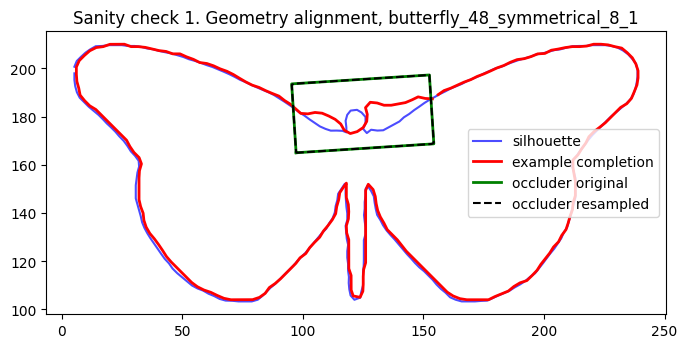

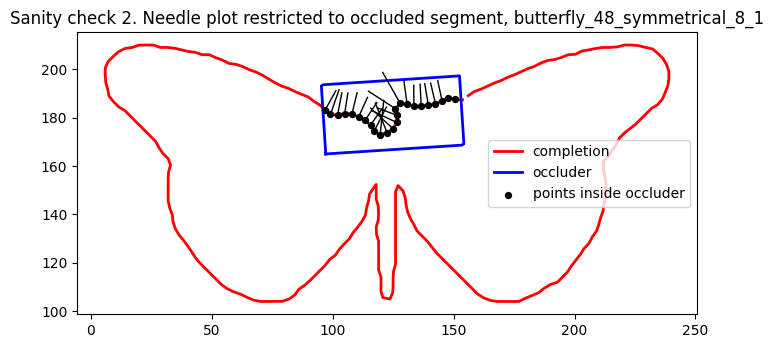

Sanity case: butterfly_48_symmetrical_8_1
baseGrid_case: 256
sil_class: butterfly
example_idx: 0
example k_argmax: 58
n_inside: 24
fs_inside_sum: 28.561482747904027
fs_inside_mean: 1.1900617811626677
fs_inside_arclen: 67.97962216267281


In [133]:
# %%
# ============================================================
# Cell 4. One-case sanity check before the big loop
# ============================================================
SANITY_CASE_ID = CASE_IDS[0]

case_dir = RESULTS_ROOT / SANITY_CASE_ID
geom_dir = GEOM_ROOT / SANITY_CASE_ID

jsonl_path = geom_dir / "generated" / f"{SANITY_CASE_ID}.jsonl"
shapes_npz = geom_dir / "generated" / "shapes_xy.npz"
components_jsonl = case_dir / "components.jsonl"
shape_to_cluster_jsonl = case_dir / "shape_to_cluster.jsonl"

assert jsonl_path.exists(), f"Missing {jsonl_path}"
assert shapes_npz.exists(), f"Missing {shapes_npz}"
assert components_jsonl.exists(), f"Missing {components_jsonl}"
assert shape_to_cluster_jsonl.exists(), f"Missing {shape_to_cluster_jsonl}"

sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(jsonl_path)
sil_px = sil_u * baseGrid_case
occ_px = occ_u * baseGrid_case
occ_px_resampled = resample_contour_arc_length(
    ensure_ccw(occ_px),
    n_points=N_POINTS_OCCLUDER,
    closed=True
)
occ_poly = Polygon(occ_px_resampled)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

npz = np.load(shapes_npz, allow_pickle=True)
polygons = npz["polygons"]

df_comp = pd.DataFrame(load_jsonl_rows(components_jsonl))
df_shape = pd.DataFrame(load_jsonl_rows(shape_to_cluster_jsonl))

df_comp_active = df_comp[df_comp["is_active"] == True].copy()
df_comp_sel = df_comp_active[df_comp_active["active_rank_by_mass_debias"] <= TOP_K_CLUSTERS].copy()
df_comp_sel = df_comp_sel.sort_values("active_rank_by_mass_debias").reset_index(drop=True)
selected_ks = set(df_comp_sel["k"].astype(int).tolist())

example_row = df_shape[df_shape["k_argmax"].isin(selected_ks)].iloc[0]
example_idx = int(example_row["global_index"])

xy_example = polygon_to_xy(polygons[example_idx], drop_duplicate_endpoint=True)
xy_example = ensure_ccw(xy_example)
xy_example_res = resample_contour_arc_length(xy_example, n_points=N_POINTS_SHAPE, closed=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(sil_px[:, 0], sil_px[:, 1], color="blue", lw=1.5, alpha=0.7, label="silhouette")
ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="example completion")

occ_closed = np.vstack([occ_px, occ_px[0]])
ax.plot(occ_closed[:, 0], occ_closed[:, 1], color="green", lw=2, label="occluder original")

occ_res_closed = np.vstack([occ_px_resampled, occ_px_resampled[0]])
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="black", lw=1.5, linestyle="--", label="occluder resampled")

ax.set_aspect("equal")
ax.set_title(f"Sanity check 1. Geometry alignment, {SANITY_CASE_ID}")
ax.legend()
plt.show()

s_norm_ex, surprisal_raw_ex, normalmap_ex, xnormals_ex, ynormals_ex = contourinfoplot_arrays(
    xy_example_res[:, 0],
    xy_example_res[:, 1],
    signed=FS_SIGNED,
    resolution=FS_RESOLUTION
)

inside_occ_ex = np.array([occ_poly.covers(Point(x, y)) for x, y in xy_example_res], dtype=bool)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(xy_example_res[:, 0], xy_example_res[:, 1], color="red", lw=2, label="completion")
ax.plot(occ_res_closed[:, 0], occ_res_closed[:, 1], color="blue", lw=2, label="occluder")

idx_inside_ex = np.where(inside_occ_ex)[0]
for i in idx_inside_ex:
    ax.plot(xnormals_ex[i], ynormals_ex[i], color="black", lw=1)

ax.scatter(
    xy_example_res[idx_inside_ex, 0],
    xy_example_res[idx_inside_ex, 1],
    s=18,
    color="black",
    zorder=3,
    label="points inside occluder"
)

ax.set_aspect("equal")
ax.set_title(f"Sanity check 2. Needle plot restricted to occluded segment, {SANITY_CASE_ID}")
ax.legend()
plt.show()

print("Sanity case:", SANITY_CASE_ID)
print("baseGrid_case:", baseGrid_case)
print("sil_class:", sil_class)
print("example_idx:", example_idx)
print("example k_argmax:", int(example_row["k_argmax"]))
print("n_inside:", int(inside_occ_ex.sum()))
print("fs_inside_sum:", float(np.sum(surprisal_raw_ex[inside_occ_ex])))
print("fs_inside_mean:", float(np.mean(surprisal_raw_ex[inside_occ_ex])) if inside_occ_ex.any() else np.nan)
print("fs_inside_arclen:", arc_length_inside_mask(xy_example_res, inside_occ_ex))

In [134]:
# %%
# ============================================================
# Cell 5. Per-case processor
# ============================================================
def process_case(case_id: str):
    case_dir = RESULTS_ROOT / case_id
    geom_dir = GEOM_ROOT / case_id

    jsonl_path = geom_dir / "generated" / f"{case_id}.jsonl"
    shapes_npz = geom_dir / "generated" / "shapes_xy.npz"
    components_jsonl = case_dir / "components.jsonl"
    shape_to_cluster_jsonl = case_dir / "shape_to_cluster.jsonl"

    assert jsonl_path.exists(), f"Missing {jsonl_path}"
    assert shapes_npz.exists(), f"Missing {shapes_npz}"
    assert components_jsonl.exists(), f"Missing {components_jsonl}"
    assert shape_to_cluster_jsonl.exists(), f"Missing {shape_to_cluster_jsonl}"

    sil_u, occ_u, baseGrid_case, sil_class = load_case_from_jsonl(jsonl_path)
    sil_px = sil_u * baseGrid_case
    occ_px = occ_u * baseGrid_case

    occ_px_resampled = resample_contour_arc_length(
        ensure_ccw(occ_px),
        n_points=N_POINTS_OCCLUDER,
        closed=True
    )

    occ_poly = Polygon(occ_px_resampled)
    if not occ_poly.is_valid:
        occ_poly = occ_poly.buffer(0)

    npz = np.load(shapes_npz, allow_pickle=True)
    polygons = npz["polygons"]

    df_comp = pd.DataFrame(load_jsonl_rows(components_jsonl))
    df_shape = pd.DataFrame(load_jsonl_rows(shape_to_cluster_jsonl))

    df_comp_active = df_comp[df_comp["is_active"] == True].copy()
    df_comp_sel = df_comp_active[df_comp_active["active_rank_by_mass_debias"] <= TOP_K_CLUSTERS].copy()
    df_comp_sel = df_comp_sel.sort_values("active_rank_by_mass_debias").reset_index(drop=True)

    assert len(df_comp_sel) > 0, f"No selected active clusters for {case_id}"

    selected_ks = set(df_comp_sel["k"].astype(int).tolist())

    mass_sum = df_comp_sel["mass_debias"].sum()
    df_comp_sel["cluster_weight"] = df_comp_sel["mass_debias"] / mass_sum

    df_shape_sel = df_shape[df_shape["k_argmax"].isin(selected_ks)].copy().reset_index(drop=True)

    tasks = df_shape_sel.to_dict(orient="records")
    occ_coords_shared = np.asarray(occ_poly.exterior.coords[:-1], dtype=float)

    with ProcessPoolExecutor(
        max_workers=N_WORKERS,
        initializer=_init_fs_worker,
        initargs=(
            polygons,
            occ_coords_shared,
            N_POINTS_SHAPE,
            FS_SIGNED,
            FS_RESOLUTION,
        ),
    ) as ex:
        rows_metrics = list(ex.map(_worker_compute_fs_metric, tasks, chunksize=32))

    df_metrics = pd.DataFrame(rows_metrics)

    cluster_hard = (
        df_metrics
        .groupby("k_argmax", as_index=False)
        .agg(
            n_shapes=("global_index", "count"),
            mean_fs_inside_sum=("fs_inside_sum", "mean"),
            mean_fs_inside_mean=("fs_inside_mean", "mean"),
            mean_fs_inside_density=("fs_inside_density", "mean"),
            mean_n_inside=("n_inside", "mean"),
            mean_arclen_inside=("arclen_inside", "mean"),
        )
        .rename(columns={"k_argmax": "k"})
    )

    cluster_hard = cluster_hard.merge(
        df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
        on="k",
        how="left"
    )

    cluster_hard["weighted_sum_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_sum"]
    cluster_hard["weighted_mean_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_mean"]
    cluster_hard["weighted_density_metric"] = cluster_hard["cluster_weight"] * cluster_hard["mean_fs_inside_density"]

    expected_fs_hard_sum = float(cluster_hard["weighted_sum_metric"].sum())
    expected_fs_hard_mean = float(cluster_hard["weighted_mean_metric"].sum())
    expected_fs_hard_density = float(cluster_hard["weighted_density_metric"].sum())

    soft_rows = []
    for _, row in df_metrics.iterrows():
        for k, p in row["resp_dict"].items():
            if k in selected_ks:
                soft_rows.append({
                    "global_index": row["global_index"],
                    "k": int(k),
                    "resp_p": float(p),
                    "fs_inside_sum": float(row["fs_inside_sum"]),
                    "fs_inside_mean": float(row["fs_inside_mean"]) if pd.notnull(row["fs_inside_mean"]) else np.nan,
                    "fs_inside_density": float(row["fs_inside_density"]) if pd.notnull(row["fs_inside_density"]) else np.nan,
                })

    df_soft = pd.DataFrame(soft_rows)

    soft_group = (
        df_soft
        .groupby("k", as_index=False)
        .apply(
            lambda g: pd.Series({
                "resp_mass_seen": g["resp_p"].sum(),
                "soft_mean_fs_inside_sum": np.average(g["fs_inside_sum"], weights=g["resp_p"]) if g["resp_p"].sum() > 0 else np.nan,
                "soft_mean_fs_inside_mean": np.average(g["fs_inside_mean"].dropna(), weights=g.loc[g["fs_inside_mean"].notna(), "resp_p"]) if g["fs_inside_mean"].notna().any() else np.nan,
                "soft_mean_fs_inside_density": np.average(g["fs_inside_density"].dropna(), weights=g.loc[g["fs_inside_density"].notna(), "resp_p"]) if g["fs_inside_density"].notna().any() else np.nan,
            })
        )
        .reset_index(drop=True)
    )

    soft_group = soft_group.merge(
        df_comp_sel[["k", "active_rank_by_mass_debias", "mass_debias", "cluster_weight"]],
        on="k",
        how="left"
    )

    soft_group["weighted_sum_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_sum"]
    soft_group["weighted_mean_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_mean"]
    soft_group["weighted_density_metric"] = soft_group["cluster_weight"] * soft_group["soft_mean_fs_inside_density"]

    expected_fs_soft_sum = float(soft_group["weighted_sum_metric"].sum())
    expected_fs_soft_mean = float(soft_group["weighted_mean_metric"].sum())
    expected_fs_soft_density = float(soft_group["weighted_density_metric"].sum())

    summary_case = {
        "case_id": case_id,
        "top_k_clusters": TOP_K_CLUSTERS,
        "n_selected_clusters": len(selected_ks),
        "n_shapes_selected_hard": len(df_metrics),
        "expected_fs_hard_sum": expected_fs_hard_sum,
        "expected_fs_hard_mean": expected_fs_hard_mean,
        "expected_fs_hard_density": expected_fs_hard_density,
        "expected_fs_soft_sum": expected_fs_soft_sum,
        "expected_fs_soft_mean": expected_fs_soft_mean,
        "expected_fs_soft_density": expected_fs_soft_density,
        "fs_signed": FS_SIGNED,
        "fs_resolution": FS_RESOLUTION,
        "n_points_shape": N_POINTS_SHAPE,
        "n_points_occluder": N_POINTS_OCCLUDER,
    }

    return summary_case

In [135]:
# %%
# ============================================================
# Cell 6. Run all 15 cases
# ============================================================
all_summaries = []

for case_id in CASE_IDS:
    print(f"Processing {case_id} ...")
    summary_case = process_case(case_id)
    all_summaries.append(summary_case)

summary_all = pd.DataFrame(all_summaries)
display(summary_all)

Processing butterfly_48_symmetrical_8_1 ...


,case_id,top_k_clusters,n_selected_clusters,n_shapes_selected_hard,expected_fs_hard_sum,expected_fs_hard_mean,expected_fs_hard_density,expected_fs_soft_sum,expected_fs_soft_mean,expected_fs_soft_density,fs_signed,fs_resolution,n_points_shape,n_points_occluder
0,butterfly_48_symmetrical_8_1,5,5,7087,32.069685,1.174081,0.413424,31.949825,1.172879,0.413099,True,3,256,128


In [136]:
# %%
# ============================================================
# Cell 7. Aggregate across the 15 runs
# ============================================================
metric_cols = [
    "expected_fs_hard_sum",
    "expected_fs_hard_mean",
    "expected_fs_hard_density",
    "expected_fs_soft_sum",
    "expected_fs_soft_mean",
    "expected_fs_soft_density",
    "n_shapes_selected_hard",
]

rows = []
n_cases = len(summary_all)

for col in metric_cols:
    vals = summary_all[col].astype(float).to_numpy()
    mean = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    se = float(sd / np.sqrt(len(vals))) if len(vals) > 0 else np.nan

    rows.append({
        "metric": col,
        "n_cases": n_cases,
        "mean": mean,
        "sd": sd,
        "se": se,
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
    })

summary_agg = pd.DataFrame(rows)
display(summary_agg)

,metric,n_cases,mean,sd,se,min,max
0,expected_fs_hard_sum,1,32.069685,0.0,0.0,32.069685,32.069685
1,expected_fs_hard_mean,1,1.174081,0.0,0.0,1.174081,1.174081
2,expected_fs_hard_density,1,0.413424,0.0,0.0,0.413424,0.413424
3,expected_fs_soft_sum,1,31.949825,0.0,0.0,31.949825,31.949825
4,expected_fs_soft_mean,1,1.172879,0.0,0.0,1.172879,1.172879
5,expected_fs_soft_density,1,0.413099,0.0,0.0,0.413099,0.413099
6,n_shapes_selected_hard,1,7087.000000,0.0,0.0,7087.000000,7087.000000


In [137]:
# %%
# ============================================================
# Cell 8. Primary result extraction
# - the main cross-run estimate is the average FS density
# ============================================================
primary = summary_agg[summary_agg["metric"] == "expected_fs_hard_density"].iloc[0]

print("Primary metric across 15 runs")
print("metric :", primary["metric"])
print("n_cases:", int(primary["n_cases"]))
print("mean   :", float(primary["mean"]))
print("sd     :", float(primary["sd"]))
print("se     :", float(primary["se"]))
print("min    :", float(primary["min"]))
print("max    :", float(primary["max"]))

Primary metric across 15 runs
metric : expected_fs_hard_density
n_cases: 1
mean   : 0.413424120404694
sd     : 0.0
se     : 0.0
min    : 0.413424120404694
max    : 0.413424120404694


In [118]:
# %%
# ============================================================
# Cell 9. Optional save
# ============================================================
OUT_DIR = RESULTS_ROOT / "_multicase_fs_summary"
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_all.to_csv(OUT_DIR / "summary_all_cases.csv", index=False)
summary_agg.to_csv(OUT_DIR / "summary_aggregate.csv", index=False)

with open(OUT_DIR / "config.json", "w") as f:
    json.dump({
        "results_root": str(RESULTS_ROOT),
        "geom_root": str(GEOM_ROOT),
        "case_ids": CASE_IDS,
        "top_k_clusters": TOP_K_CLUSTERS,
        "n_points_shape": N_POINTS_SHAPE,
        "n_points_occluder": N_POINTS_OCCLUDER,
        "fs_signed": FS_SIGNED,
        "fs_resolution": FS_RESOLUTION,
        "n_workers": N_WORKERS,
    }, f, indent=2)

print("Saved to:", OUT_DIR)

Saved to: /home/hschatzle/monte-carlo-selection/results/symmetry/bgmm_butterfly_symmetrical_texture_6/_multicase_fs_summary


# Visualization

,case_id,top_k_clusters,n_selected_clusters,n_shapes_selected_hard,expected_fs_hard_sum,expected_fs_hard_mean,expected_fs_hard_density,expected_fs_soft_sum,expected_fs_soft_mean,expected_fs_soft_density,fs_signed,fs_resolution,n_points_shape,n_points_occluder,condition,network,info,size
0,elephant_7_low_large_1,5,5,8285,23.133745,1.109074,0.221904,23.013441,1.107075,0.221530,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
1,elephant_7_low_large_2,5,5,5928,21.922787,1.088095,0.218253,21.623269,1.081983,0.217104,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
2,elephant_7_low_large_3,5,5,7856,22.968000,1.107928,0.222033,22.845523,1.105760,0.221646,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
3,elephant_7_low_large_4,5,5,6404,22.267472,1.093583,0.219324,22.088423,1.090040,0.218675,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large
4,elephant_7_low_large_5,5,5,7183,22.615122,1.100165,0.220583,22.505774,1.098423,0.220302,True,3,256,128,bgmm_elephant_texture_low_large,texture,low,large



Aggregated summary:


,network,info,size,n_runs,fs_density_mean,fs_density_sd,fs_density_se,fs_mean_mean,fs_sum_mean
0,texture,low,small,15,0.206257,0.019455,0.005023,0.796007,5.058350
1,texture,high,small,15,0.216160,0.005350,0.001381,0.847761,5.590527
2,shape,low,small,15,0.201396,0.005458,0.001409,0.799994,4.954970
3,shape,high,small,15,0.265682,0.003634,0.000938,1.054207,8.818684
4,texture,low,large,15,0.219903,0.002202,0.000568,1.096921,22.427604
5,texture,high,large,15,0.250206,0.001842,0.000476,1.245194,31.120773
6,shape,low,large,15,0.237949,0.005400,0.001394,1.195726,27.571767
7,shape,high,large,15,0.241830,0.001962,0.000506,1.195310,27.932943


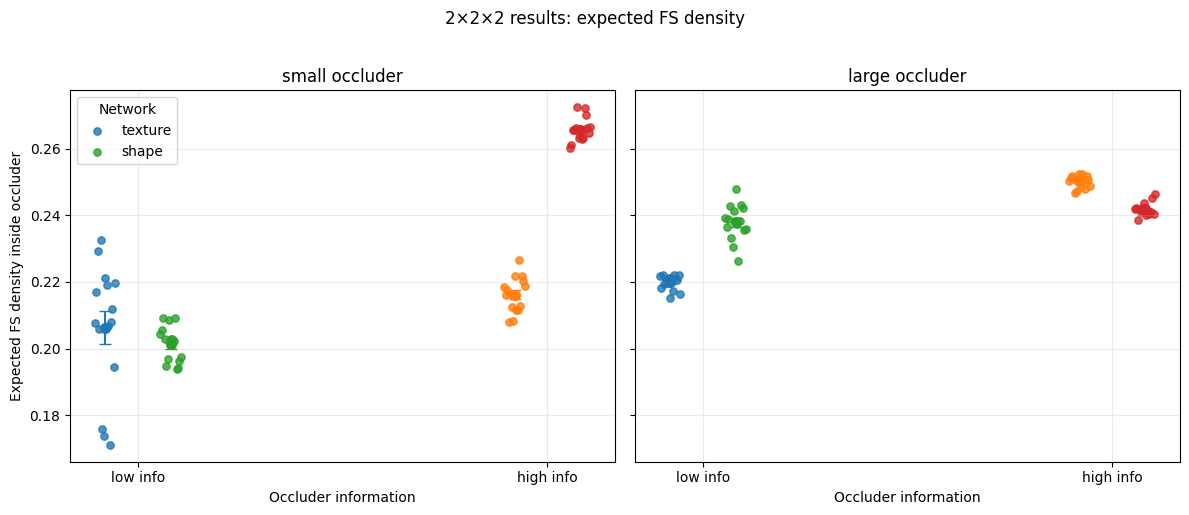

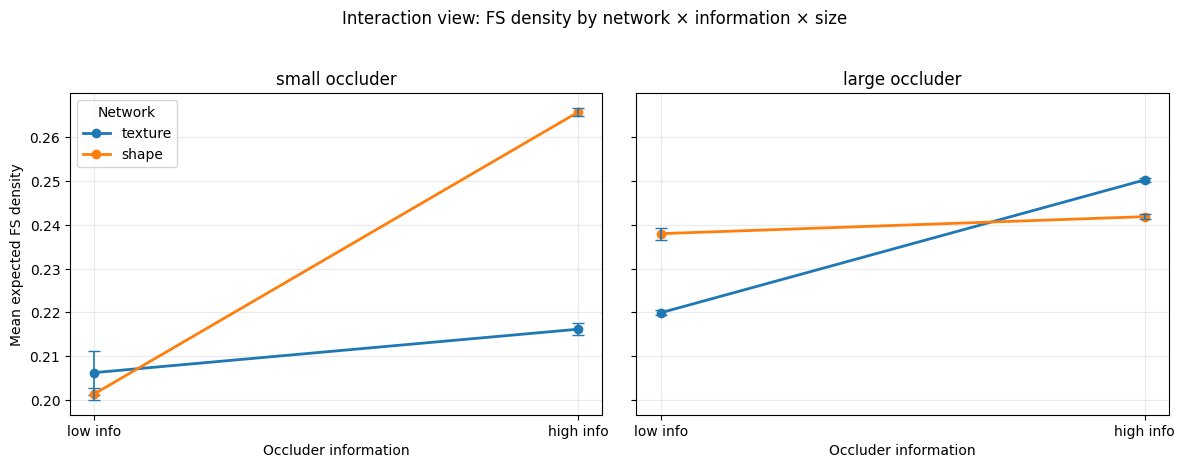

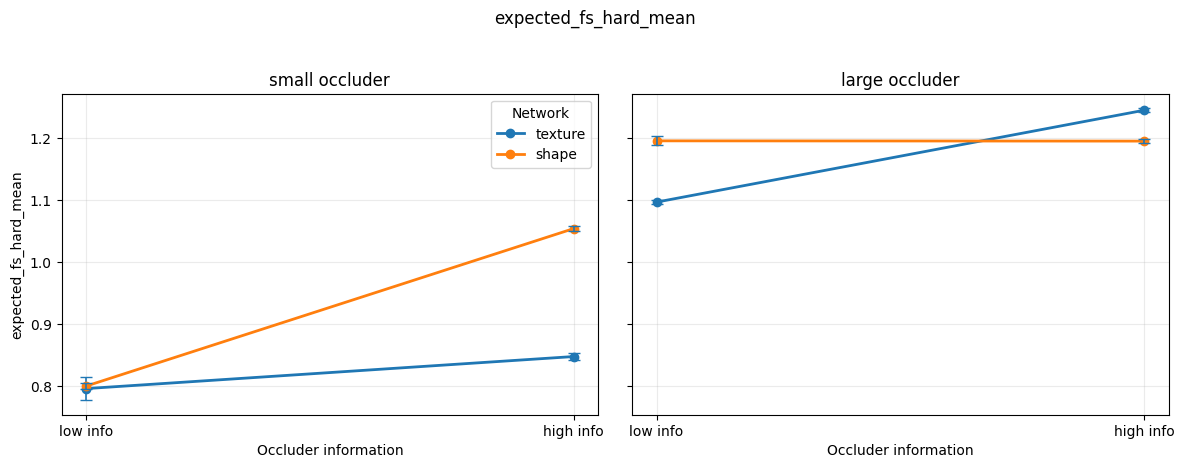

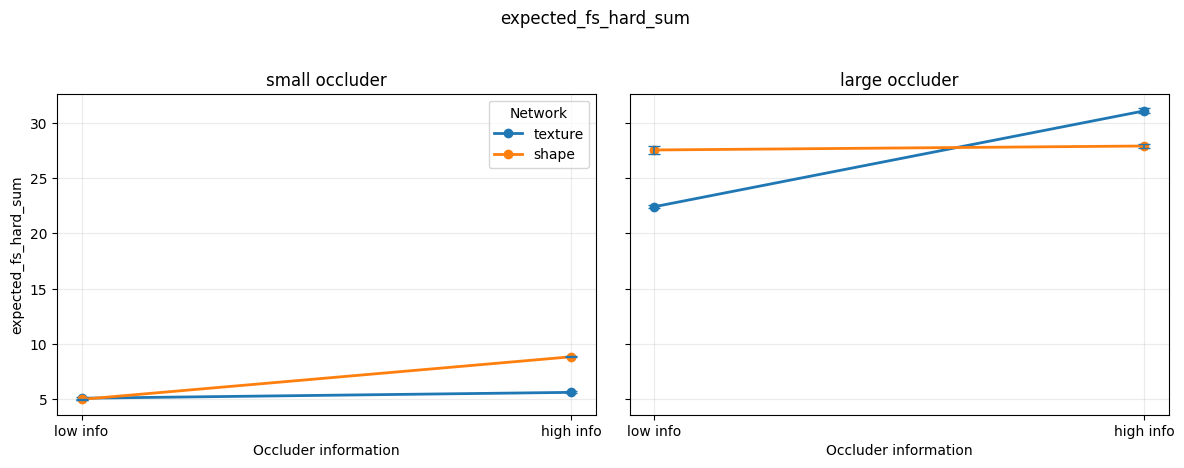

In [78]:
# %%
# ============================================================
# Plot 2x2x2 results from multicase CSV summaries
# - reads summary_all_cases.csv from each condition folder
# - plots per-run points + condition means for:
#     expected_fs_hard_density   (primary)
#     expected_fs_hard_mean
#     expected_fs_hard_sum
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/home/hschatzle/monte-carlo-selection/results/contrasts")

CONDITION_DIRS = [
    "bgmm_elephant_texture_low_large",
    "bgmm_elephant_shape_low_large",
    "bgmm_elephant_texture_high_large",
    "bgmm_elephant_shape_high_large",
    "bgmm_elephant_texture_low_small",
    "bgmm_elephant_shape_low_small",
    "bgmm_elephant_texture_high_small",
    "bgmm_elephant_shape_high_small",
]

PRIMARY_METRIC = "expected_fs_hard_density"
OTHER_METRICS = ["expected_fs_hard_mean", "expected_fs_hard_sum"]

# ----------------------------
# load all condition csvs
# ----------------------------
rows = []

for cond in CONDITION_DIRS:
    csv_path = ROOT / cond / "_multicase_fs_summary" / "summary_all_cases.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["condition"] = cond

    # parse factors from folder name: bgmm_elephant_{network}_{info}_{size}
    parts = cond.split("_")
    if len(parts) < 5:
        raise ValueError(f"Unexpected condition folder name: {cond}")

    network = parts[2]   # texture / shape
    info = parts[3]      # low / high
    size = parts[4]      # small / large

    df["network"] = network
    df["info"] = info
    df["size"] = size

    rows.append(df)

all_df = pd.concat(rows, ignore_index=True)

# enforce categorical order
all_df["network"] = pd.Categorical(all_df["network"], categories=["texture", "shape"], ordered=True)
all_df["info"] = pd.Categorical(all_df["info"], categories=["low", "high"], ordered=True)
all_df["size"] = pd.Categorical(all_df["size"], categories=["small", "large"], ordered=True)

display(all_df.head())

# ----------------------------
# aggregated summary table
# ----------------------------
summary = (
    all_df
    .groupby(["network", "info", "size"], as_index=False)
    .agg(
        n_runs=("case_id", "count"),
        fs_density_mean=(PRIMARY_METRIC, "mean"),
        fs_density_sd=(PRIMARY_METRIC, "std"),
        fs_density_se=(PRIMARY_METRIC, lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        fs_mean_mean=("expected_fs_hard_mean", "mean"),
        fs_sum_mean=("expected_fs_hard_sum", "mean"),
    )
    .sort_values(["size", "network", "info"])
    .reset_index(drop=True)
)

print("\nAggregated summary:")
display(summary)

# ----------------------------
# helper for x positions
# ----------------------------
x_map = {"low": 0, "high": 1}
offset_map = {"texture": -0.08, "shape": 0.08}

# ----------------------------
# Figure 1: primary metric, faceted by occluder size
# per-run points + mean ± SE
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, size in zip(axes, ["small", "large"]):
    sub = all_df[all_df["size"] == size].copy()

    for network in ["texture", "shape"]:
        s = sub[sub["network"] == network].copy()

        for info in ["low", "high"]:
            ss = s[s["info"] == info].copy()
            x = x_map[info] + offset_map[network]

            # deterministic tiny horizontal spread for visibility
            if len(ss) > 1:
                jitter = np.linspace(-0.025, 0.025, len(ss))
            else:
                jitter = np.array([0.0])

            ax.scatter(
                np.full(len(ss), x) + jitter,
                ss[PRIMARY_METRIC].to_numpy(),
                s=28,
                alpha=0.8,
                label=network if info == "low" else None
            )

            m = ss[PRIMARY_METRIC].mean()
            se = ss[PRIMARY_METRIC].std(ddof=1) / np.sqrt(len(ss)) if len(ss) > 1 else 0.0

            ax.errorbar(
                x, m, yerr=se,
                fmt="o",
                capsize=4,
                markersize=7,
                linewidth=1.5
            )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["low info", "high info"])
    ax.set_title(f"{size} occluder")
    ax.set_xlabel("Occluder information")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Expected FS density inside occluder")
axes[0].legend(title="Network")
fig.suptitle("2×2×2 results: expected FS density", y=1.02)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 2: compact interaction plot for the primary metric
# one panel per size, lines connect low/high for each network
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, size in zip(axes, ["small", "large"]):
    ssum = summary[summary["size"] == size].copy()

    for network in ["texture", "shape"]:
        ss = ssum[ssum["network"] == network].sort_values("info")
        xs = [x_map[i] for i in ss["info"]]
        ys = ss["fs_density_mean"].to_numpy()
        ses = ss["fs_density_se"].to_numpy()

        ax.plot(xs, ys, marker="o", linewidth=2, label=network)
        ax.errorbar(xs, ys, yerr=ses, fmt="none", capsize=4, linewidth=1.2)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["low info", "high info"])
    ax.set_title(f"{size} occluder")
    ax.set_xlabel("Occluder information")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Mean expected FS density")
axes[0].legend(title="Network")
fig.suptitle("Interaction view: FS density by network × information × size", y=1.03)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 3: same layout for additional metrics
# ----------------------------
for metric in OTHER_METRICS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

    for ax, size in zip(axes, ["small", "large"]):
        sub = all_df[all_df["size"] == size].copy()

        for network in ["texture", "shape"]:
            s = sub[sub["network"] == network].copy()
            means = []
            ses = []

            for info in ["low", "high"]:
                ss = s[s["info"] == info].copy()
                means.append(ss[metric].mean())
                ses.append(ss[metric].std(ddof=1) / np.sqrt(len(ss)) if len(ss) > 1 else 0.0)

            xs = [0, 1]
            ax.plot(xs, means, marker="o", linewidth=2, label=network)
            ax.errorbar(xs, means, yerr=ses, fmt="none", capsize=4, linewidth=1.2)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["low info", "high info"])
        ax.set_title(f"{size} occluder")
        ax.set_xlabel("Occluder information")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(metric)
    axes[0].legend(title="Network")
    fig.suptitle(metric, y=1.03)
    plt.tight_layout()
    plt.show()

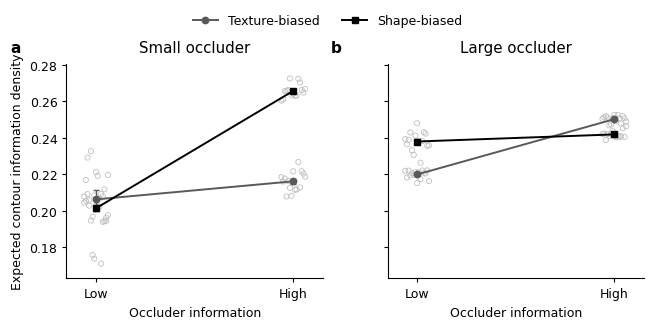

Saved editable SVG to:
/home/hschatzle/monte-carlo-selection/results/contrasts/nature_style_fs_interaction.svg


In [79]:
# %%
# ============================================================
# Nature-style 2-panel interaction plot
# - reads summary_all_cases.csv from all 8 condition folders
# - plots per-run points + mean ± SE
# - saves editable SVG
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/home/hschatzle/monte-carlo-selection/results/contrasts")

CONDITION_DIRS = [
    "bgmm_elephant_texture_low_large",
    "bgmm_elephant_shape_low_large",
    "bgmm_elephant_texture_high_large",
    "bgmm_elephant_shape_high_large",
    "bgmm_elephant_texture_low_small",
    "bgmm_elephant_shape_low_small",
    "bgmm_elephant_texture_high_small",
    "bgmm_elephant_shape_high_small",
]

PRIMARY_METRIC = "expected_fs_hard_density"
OUT_SVG = ROOT / "nature_style_fs_interaction.svg"

# ------------------------------------------------------------
# Load all condition-level run summaries
# ------------------------------------------------------------
dfs = []

for cond in CONDITION_DIRS:
    csv_path = ROOT / cond / "_multicase_fs_summary" / "summary_all_cases.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    df["condition"] = cond

    # Parse folder name: bgmm_elephant_{network}_{info}_{size}
    parts = cond.split("_")
    network = parts[2]   # texture / shape
    info = parts[3]      # low / high
    size = parts[4]      # small / large

    df["network"] = network
    df["info"] = info
    df["size"] = size

    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

all_df["network"] = pd.Categorical(all_df["network"], categories=["texture", "shape"], ordered=True)
all_df["info"] = pd.Categorical(all_df["info"], categories=["low", "high"], ordered=True)
all_df["size"] = pd.Categorical(all_df["size"], categories=["small", "large"], ordered=True)

# ------------------------------------------------------------
# Aggregate mean and SE for plotting
# ------------------------------------------------------------
summary = (
    all_df
    .groupby(["network", "info", "size"], as_index=False)
    .agg(
        n_runs=("case_id", "count"),
        mean_value=(PRIMARY_METRIC, "mean"),
        sd_value=(PRIMARY_METRIC, lambda x: np.std(x, ddof=1)),
        se_value=(PRIMARY_METRIC, lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
    )
)

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
# Monochrome, Nature-friendly
style_map = {
    "texture": {"color": "0.35", "marker": "o", "label": "Texture-biased"},
    "shape":   {"color": "0.00", "marker": "s", "label": "Shape-biased"},
}

x_map = {"low": 0, "high": 1}
panel_order = ["small", "large"]
panel_title = {"small": "Small occluder", "large": "Large occluder"}

# Shared y-limits with a bit of padding
y = all_df[PRIMARY_METRIC].to_numpy()
ymin = y.min()
ymax = y.max()
ypad = 0.08 * (ymax - ymin)
ylim = (ymin - ypad, ymax + ypad)

plt.rcParams.update({
    "font.size": 9,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "svg.fonttype": "none",   # keep text editable in SVG
})

fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.2), sharey=True)

for ax, size in zip(axes, panel_order):
    panel_df = all_df[all_df["size"] == size].copy()
    panel_summary = summary[summary["size"] == size].copy()

    # per-run points
    for network in ["texture", "shape"]:
        spec = style_map[network]
        net_df = panel_df[panel_df["network"] == network].copy()

        for info in ["low", "high"]:
            sub = net_df[net_df["info"] == info].copy()
            x0 = x_map[info]

            # deterministic jitter so figure is reproducible
            n = len(sub)
            jitter = np.linspace(-0.06, 0.06, n) if n > 1 else np.array([0.0])

            ax.scatter(
                np.full(n, x0) + jitter,
                sub[PRIMARY_METRIC].to_numpy(),
                s=14,
                facecolors="none",
                edgecolors="0.75",
                linewidths=0.6,
                zorder=1
            )

    # mean ± SE lines
    for network in ["texture", "shape"]:
        spec = style_map[network]
        sub = panel_summary[panel_summary["network"] == network].sort_values("info")

        xs = np.array([x_map[i] for i in sub["info"]], dtype=float)
        ys = sub["mean_value"].to_numpy()
        ses = sub["se_value"].to_numpy()

        ax.plot(
            xs, ys,
            color=spec["color"],
            linewidth=1.4,
            marker=spec["marker"],
            markersize=4.6,
            label=spec["label"],
            zorder=3
        )

        ax.errorbar(
            xs, ys, yerr=ses,
            fmt="none",
            ecolor=spec["color"],
            elinewidth=1.0,
            capsize=2.5,
            zorder=2
        )

    # cosmetics
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(*ylim)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low", "High"])
    ax.set_xlabel("Occluder information")
    ax.set_title(panel_title[size], pad=8)

    # Nature-like minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

# y-label only once
axes[0].set_ylabel("Expected contour information density")

# panel letters
axes[0].text(-0.22, 1.04, "a", transform=axes[0].transAxes, fontsize=11, fontweight="bold", va="bottom")
axes[1].text(-0.22, 1.04, "b", transform=axes[1].transAxes, fontsize=11, fontweight="bold", va="bottom")

# legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=2,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.8
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save editable SVG
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight")
plt.show()

print("Saved editable SVG to:")
print(OUT_SVG)

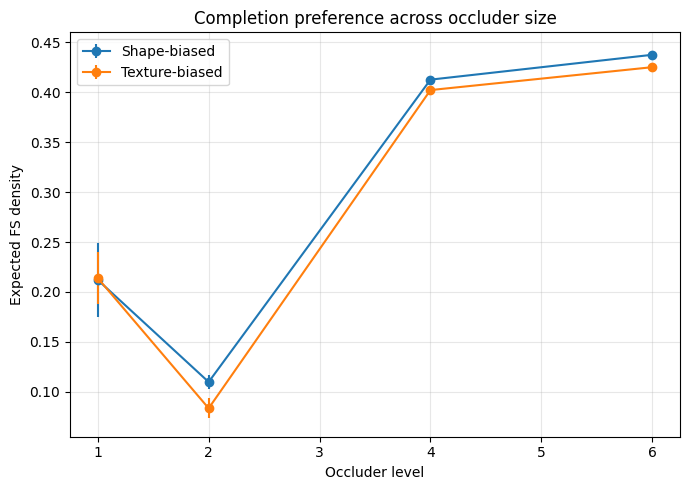

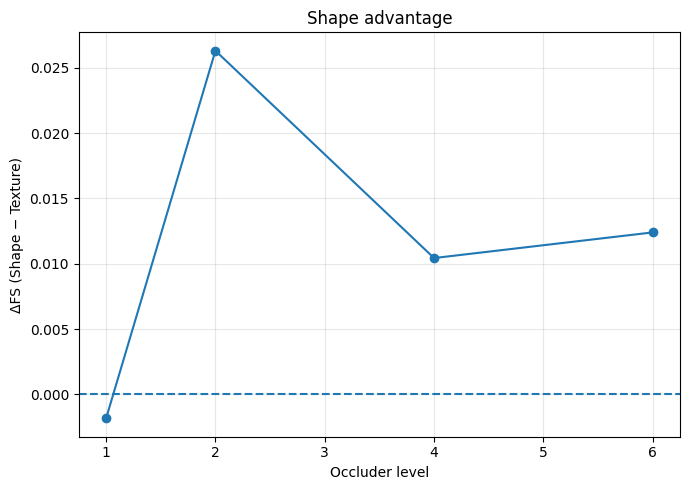

In [128]:
# %%
# ============================================================
# Plot FS curves across occluder levels
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Specify experiment folders
# Each folder must contain: summary_aggregate.csv
# ------------------------------------------------------------
BASE = Path("/home/hschatzle/monte-carlo-selection/results/symmetry")

PATHS = {
    "shape": {
        1: BASE / "bgmm_butterfly_symmetrical_shape_1/_multicase_fs_summary/summary_aggregate.csv",
        2: BASE / "bgmm_butterfly_symmetrical_shape_2/_multicase_fs_summary/summary_aggregate.csv",
        4: BASE / "bgmm_butterfly_symmetrical_shape_4/_multicase_fs_summary/summary_aggregate.csv",
        6: BASE / "bgmm_butterfly_symmetrical_shape_6/_multicase_fs_summary/summary_aggregate.csv",
        #8: BASE / "shape_lvl8/_multicase_fs_summary/summary_aggregate.csv",
    },
    "texture": {
        1: BASE / "bgmm_butterfly_symmetrical_texture_1/_multicase_fs_summary/summary_aggregate.csv",
        2: BASE / "bgmm_butterfly_symmetrical_texture_2/_multicase_fs_summary/summary_aggregate.csv",
        4: BASE / "bgmm_butterfly_symmetrical_texture_4/_multicase_fs_summary/summary_aggregate.csv",
        6: BASE / "bgmm_butterfly_symmetrical_texture_6/_multicase_fs_summary/summary_aggregate.csv",
        #8: BASE / "texture_lvl8/_multicase_fs_summary/summary_aggregate.csv",
    }
}

# ------------------------------------------------------------
# Helper: extract FS density mean
# ------------------------------------------------------------
def load_fs_density(csv_path):

    df = pd.read_csv(csv_path)

    row = df[df["metric"] == "expected_fs_hard_density"]

    if len(row) == 0:
        raise ValueError(f"No expected_fs_hard_density row in {csv_path}")

    return row["mean"].values[0], row["se"].values[0]


# ------------------------------------------------------------
# Load all levels
# ------------------------------------------------------------
levels = sorted(PATHS["shape"].keys())

shape_mean = []
shape_se = []

texture_mean = []
texture_se = []

for lvl in levels:

    m, se = load_fs_density(PATHS["shape"][lvl])
    shape_mean.append(m)
    shape_se.append(se)

    m, se = load_fs_density(PATHS["texture"][lvl])
    texture_mean.append(m)
    texture_se.append(se)


# ------------------------------------------------------------
# Compute delta
# ------------------------------------------------------------
delta = [s - t for s, t in zip(shape_mean, texture_mean)]


# ------------------------------------------------------------
# Plot 1: FS curves
# ------------------------------------------------------------
plt.figure(figsize=(7,5))

plt.errorbar(levels, shape_mean, yerr=shape_se, marker="o", label="Shape-biased")
plt.errorbar(levels, texture_mean, yerr=texture_se, marker="o", label="Texture-biased")

plt.xlabel("Occluder level")
plt.ylabel("Expected FS density")
plt.title("Completion preference across occluder size")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: Delta FS
# ------------------------------------------------------------
plt.figure(figsize=(7,5))

plt.plot(levels, delta, marker="o")

plt.axhline(0, linestyle="--")

plt.xlabel("Occluder level")
plt.ylabel("ΔFS (Shape − Texture)")
plt.title("Shape advantage")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()